# 1 Operazioni preliminari

In questa sezione preliminare vengono importate le librerie potenzialmente utili e vengono implementate alcune impostazioni grafiche e di output. Infine viene importato il dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing, splitting, pipeline e gestione dei dati mancanti
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#modelli
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

#metriche
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#finetuning e learning curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve

#gestione dell'eventuale sbilanciamento nella target
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Interpretabilità
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance
import shap

#impostazioni grafiche e di output
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) #per ignorare warning comuni
warnings.filterwarnings('ignore', category=UserWarning) #per ignorare warning nel caso di categorie sconosciute per OHE
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (6, 5)

RANDOM_STATE = 1996 #per la riproducibilità

print(">>>>> Librerie importate con successo\n")

#import dati
url='https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv'
df = pd.read_csv(url,index_col=0) #omissione prima colonna con indice
print(">>>>> Import dataset completato\n")
print(f">>>>> Info dataset:\nNumero di righe: {df.shape[0]}, Numero di colonne: {df.shape[1]}")

>>>>> Librerie importate con successo

>>>>> Import dataset completato

>>>>> Info dataset:
Numero di righe: 338427, Numero di colonne: 18


# 2 Esplorazione del dataset

In questa sezione viene esplorato il dataset nella sua struttura generale.<br>
Primariamente si cerca di comprendere la struttura del datase, poi viene mostrata l'analisi dei dati mancanti e la strategia per gestirli. Successivamente viene condotta un'analisi descrittiva e successivamente vengono analizzate, in base alla natura, le variabili (quindi la variabile target e le features numeriche e categoriche).

###2.1 Generalità del dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338427 entries, 5008804 to 6392180
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          338427 non-null  object 
 1   FLAG_OWN_CAR         338427 non-null  object 
 2   FLAG_OWN_REALTY      338427 non-null  object 
 3   CNT_CHILDREN         338427 non-null  int64  
 4   AMT_INCOME_TOTAL     338427 non-null  float64
 5   NAME_INCOME_TYPE     338427 non-null  object 
 6   NAME_EDUCATION_TYPE  338427 non-null  object 
 7   NAME_FAMILY_STATUS   338426 non-null  object 
 8   NAME_HOUSING_TYPE    338426 non-null  object 
 9   DAYS_BIRTH           338426 non-null  float64
 10  DAYS_EMPLOYED        338426 non-null  float64
 11  FLAG_MOBIL           338426 non-null  float64
 12  FLAG_WORK_PHONE      338426 non-null  float64
 13  FLAG_PHONE           338426 non-null  float64
 14  FLAG_EMAIL           338426 non-null  float64
 15  OCCUPATION_TYPE

Le variabili presenti nel dataset sono le seguenti.
* ID: numero identificativo del cliente (omessa in fase di import del dataset)
* CODE_GENDER: sesso del cliente
* FLAG_OWN_CAR: indicatore del possesso di un'automobile
* FLAG_OWN_REALTY: indicatore del possesso di una casa
* CNT_CHILDREN: numero di figli
* AMT_INCOME_TOTAL: reddito annuale
* NAME_INCOME_TYPE: tipo di reddito
* NAME_EDUCATION_TYPE: livello di educazione
* NAME_FAMILY_STATUS: stato civile
* NAME_HOUSING_TYPE: tipo di abitazione
* DAYS_BIRTH: numero di giorni trascorsi dalla nascita
* DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)
* FLAG_MOBIL: indicatore della presenza di un numero di cellulare
* FLAGWORKPHONE: indicatore della presenza di un numero di telefono di lavoro
* FLAG_PHONE: indicatore della presenza di un numero di telefono
* FLAG_EMAIL: indicatore della presenza di un indirizzo email
* OCCUPATION_TYPE: tipo di occupazione
* CNT_FAM_MEMBERS: numero di familiari
* TARGET: variabile che vale 1 se il cliente ha una elevata affidabilità creditizia (pagamento costante delle rate), 0 altrimenti.

<br>
Le variabili di tipo numerico sono:CNT_CHILDREN, AMT_INCOME_TOTAL, DAYS_BIRTH, DAYS_EMPLOYED, CNT_FAM_MEMBERS. Tutte le altre sono categoriche.

In [3]:
df.head(10)

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
ID,,,,,,,,,,,,,,,,,,
5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5008810,F,N,Y,0,265679.04,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18826.0,-3130.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5008811,F,N,Y,0,271761.74,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19020.0,-3094.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5008812,F,N,Y,0,293089.84,Pensioner,Higher education,Separated,House / apartment,-22090.0,372399.0,1.0,0.0,0.0,0.0,NaN,1.0,0
5008813,F,N,Y,0,286928.42,Pensioner,Higher education,Separated,House / apartment,-22179.0,360576.0,1.0,0.0,0.0,0.0,NaN,1.0,0


Osservazione: i valori negativi di DAYS_BIRTH hanno senso, infatti in molti casi, specialmente in dataset finanziari o bancari, le età (o altri riferimenti temporali), vengono registrate come giorni passati rispetto a una certa data di riferimento. La gestione di ciò verrà fatta in sede di analisi della feature.

###2.2 Dati mancanti e gestione

In [4]:
missing_data = df.isnull().sum()
missing_perc = (missing_data / len(df)) * 100
missing_table = pd.concat([missing_data, missing_perc], axis=1, keys=['Valori mancanti', '%'])
print(missing_table[missing_table['Valori mancanti'] > 0].sort_values('%', ascending=False))


                    Valori mancanti          %
OCCUPATION_TYPE              103342  30.535980
NAME_FAMILY_STATUS                1   0.000295
NAME_HOUSING_TYPE                 1   0.000295
DAYS_BIRTH                        1   0.000295
FLAG_MOBIL                        1   0.000295
DAYS_EMPLOYED                     1   0.000295
FLAG_WORK_PHONE                   1   0.000295
FLAG_PHONE                        1   0.000295
FLAG_EMAIL                        1   0.000295
CNT_FAM_MEMBERS                   1   0.000295


OCCUPATION_TYPE ha quasi il 31% di valori mancanti, quindi una percentuale significativa.<br>
<br>
Strategia di gestione dei valori mancanti e di imputazione:
* OCCUPATION_TYPE: data la notevole quantità di valori mancanti si usa la seguente strategia.<br>
1) Pensionati (Pensioner): Per i clienti il cui
NAME_INCOME_TYPE è Pensioner e OCCUPATION_TYPE è mancante (che sono il 100% dei pensionati), verrà assegnata una nuova categoria Pensioner_Retired. Questo è più informativo di "Mancante".<br>
2) Studenti (Student): Per gli studenti con OCCUPATION_TYPE mancante, verrà assegnato Student_Unemployed/Other. Ciò riflette la loro condizione primaria e la possibilità che non abbiano un'occupazione formale.<br>
3) Altre categorie di reddito (Working, Commercial associate, State servant): Per i valori mancanti di OCCUPATION_TYPE in queste categorie, verranno create etichette più specifiche come Working_UnknownOccupation, Commercial_UnknownOccupation, e StateServant_UnknownOccupation. Ciò fornirà un contesto leggermente migliore rispetto a un "Mancante" generico.
* DAYS_BIRTH, DAYS_EMPLOYED, CNT_FAM_MEMBERS: sono varabili numeriche, quindi ai valori mancanti verrà imputata la media.
* NAME_FAMILY_STATUS, NAME_HOUSING_TYPE: sono variabili categoriche, quindi da imputare con la moda.
* FLAG_MOBIL, FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL: sono variabili binarie (assimilabili alle categoriche) quindi da imputare con la moda.

In [5]:
#gestione dei valori mancanti per OCCUPATION_TYPE basata su (tenendo conto di) NAME_INCOME_TYPE
col_occupation = 'OCCUPATION_TYPE'
col_income_type = 'NAME_INCOME_TYPE'

print(f"\n>>>>> Inizio gestione valori mancanti per '{col_occupation}' in base a '{col_income_type}'...")
missing_before = df[col_occupation].isnull().sum()
if missing_before > 0:
    print(f"Valori mancanti in '{col_occupation}' prima dell'imputazione specifica: {missing_before}")

    #step 1: pensionati
    #per NAME_INCOME_TYPE == 'Pensioner', OCCUPATION_TYPE NaN diventa Pensioner_Retired
    pensioner_mask = (df[col_income_type] == 'Pensioner') & (df[col_occupation].isnull())
    df.loc[pensioner_mask, col_occupation] = 'Pensioner_Retired'
    imputed_pensioner = pensioner_mask.sum()
    if imputed_pensioner > 0:
        print(f"  - Imputati {imputed_pensioner} valori per 'Pensioner' come 'Pensioner_Retired'")

    #step 2: studenti
    #per NAME_INCOME_TYPE == 'Student', OCCUPATION_TYPE NaN diventa Student_Unemployed/Other
    student_mask = (df[col_income_type] == 'Student') & (df[col_occupation].isnull())
    df.loc[student_mask, col_occupation] = 'Student_Unemployed/Other'
    imputed_student = student_mask.sum()
    if imputed_student > 0:
        print(f"  - Imputati {imputed_student} valori per 'Student' come 'Student_Unemployed/Other'")

    #step 3: altre categorie di lavoratori con OCCUPATION_TYPE mancante
    #creazione categorie più specifiche come Working_UnknownOccupation

    #lavoratori dipendenti (Working)
    working_mask = (df[col_income_type] == 'Working') & (df[col_occupation].isnull())
    df.loc[working_mask, col_occupation] = 'Working_UnknownOccupation'
    imputed_working = working_mask.sum()
    if imputed_working > 0:
        print(f"  - Imputati {imputed_working} valori per 'Working' come 'Working_UnknownOccupation'")

    #associati commerciali (Commercial associate)
    commercial_mask = (df[col_income_type] == 'Commercial associate') & (df[col_occupation].isnull())
    df.loc[commercial_mask, col_occupation] = 'Commercial_UnknownOccupation'
    imputed_commercial = commercial_mask.sum()
    if imputed_commercial > 0:
        print(f"  - Imputati {imputed_commercial} valori per 'Commercial associate' come 'Commercial_UnknownOccupation'")

    #dipendenti statali (State servant)
    state_mask = (df[col_income_type] == 'State servant') & (df[col_occupation].isnull())
    df.loc[state_mask, col_occupation] = 'StateServant_UnknownOccupation'
    imputed_state = state_mask.sum()
    if imputed_state > 0:
        print(f"  - Imputati {imputed_state} valori per 'State servant' come 'StateServant_UnknownOccupation'")

    #controllo per eventuali NaN residui (se tutte le categorie di NAME_INCOME_TYPE sono state coperte allora 0)
    remaining_nans = df[col_occupation].isnull().sum()
    if remaining_nans > 0:
        print(f"  - ATTENZIONE: Rimangono {remaining_nans} valori NaN in '{col_occupation}'. Verranno imputati come 'Generic_UnknownOccupation'.")
        df[col_occupation] = df[col_occupation].fillna('Generic_UnknownOccupation')

    missing_after = df[col_occupation].isnull().sum()
    if missing_after == 0:
        print(f"  - Tutti i {missing_before} valori mancanti in '{col_occupation}' sono stati gestiti.")
    else:
        print(f"  - ATTENZIONE: Dopo l'imputazione specifica, rimangono {missing_after} valori NaN in '{col_occupation}'.")

    print(">>>>> Gestione valori mancanti per OCCUPATION_TYPE completata.\n")

    #nuove categorie create in OCCUPATION_TYPE
    print(">>>>> Nuove categorie e conteggi in OCCUPATION_TYPE dopo imputazione specifica:")
    print(df[col_occupation].value_counts(dropna=False).head(25)) #mostra le prime 25 per brevità
    print("-" * 50)

else:
    print(f"Nessun valore mancante trovato per '{col_occupation}'. Non è necessaria alcuna imputazione.\n")


>>>>> Inizio gestione valori mancanti per 'OCCUPATION_TYPE' in base a 'NAME_INCOME_TYPE'...
Valori mancanti in 'OCCUPATION_TYPE' prima dell'imputazione specifica: 103342
  - Imputati 57841 valori per 'Pensioner' come 'Pensioner_Retired'
  - Imputati 5 valori per 'Student' come 'Student_Unemployed/Other'
  - Imputati 27784 valori per 'Working' come 'Working_UnknownOccupation'
  - Imputati 12927 valori per 'Commercial associate' come 'Commercial_UnknownOccupation'
  - Imputati 4785 valori per 'State servant' come 'StateServant_UnknownOccupation'
  - Tutti i 103342 valori mancanti in 'OCCUPATION_TYPE' sono stati gestiti.
>>>>> Gestione valori mancanti per OCCUPATION_TYPE completata.

>>>>> Nuove categorie e conteggi in OCCUPATION_TYPE dopo imputazione specifica:
OCCUPATION_TYPE
Laborers                          60146
Pensioner_Retired                 57841
Core staff                        33527
Sales staff                       31652
Working_UnknownOccupation         27784
Managers     

In [6]:
#da imputare con la media
cols_for_mean_imputation = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS']
for col in cols_for_mean_imputation:
  if df[col].isnull().sum() > 0:
      df[col] = df[col].fillna(df[col].mean())
      print(f"Imputazione valori mancanti per '{col}' con la MEDIA ({df[col].mean():.2f})\nEsito: ok\n")

#da imputare con la moda (per categoriche e binarie)
cols_for_mode_imputation = ['NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                            'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
for col in cols_for_mode_imputation:
  if df[col].isnull().sum() > 0:
      mode_val = df[col].mode()[0] #calcolo della moda e prende la prima in caso di multimodalità
      df[col] = df[col].fillna(mode_val)
      print(f"Imputazione valori mancanti per '{col}' con la MODA ('{mode_val}')\nEsito: ok\n")

#verifica dei dati mancanti dopo imputazione
missing_after_imputation = df.isnull().sum()
print(missing_after_imputation[missing_after_imputation > 0])
if missing_after_imputation.sum() == 0:
    print("Nessun valore mancante residuo nel dataset.")
else:
    print("Ci sono ancora valori mancanti da gestire")

missing_after_imputation

Imputazione valori mancanti per 'DAYS_BIRTH' con la MEDIA (-15998.21)
Esito: ok

Imputazione valori mancanti per 'DAYS_EMPLOYED' con la MEDIA (60234.53)
Esito: ok

Imputazione valori mancanti per 'CNT_FAM_MEMBERS' con la MEDIA (2.20)
Esito: ok

Imputazione valori mancanti per 'NAME_FAMILY_STATUS' con la MODA ('Married')
Esito: ok

Imputazione valori mancanti per 'NAME_HOUSING_TYPE' con la MODA ('House / apartment')
Esito: ok

Imputazione valori mancanti per 'FLAG_MOBIL' con la MODA ('1.0')
Esito: ok

Imputazione valori mancanti per 'FLAG_WORK_PHONE' con la MODA ('0.0')
Esito: ok

Imputazione valori mancanti per 'FLAG_PHONE' con la MODA ('0.0')
Esito: ok

Imputazione valori mancanti per 'FLAG_EMAIL' con la MODA ('0.0')
Esito: ok

Series([], dtype: int64)
Nessun valore mancante residuo nel dataset.


,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
DAYS_BIRTH,0


###2.3 Statistiche descrittive

In [7]:
#statistiche descrittive per le feature numeriche
numerical_cols_for_describe = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_FAM_MEMBERS'
]
#filtra sul dataset
numerical_cols_for_describe_present = [col for col in numerical_cols_for_describe if col in df.columns]

if numerical_cols_for_describe_present:
    print(">>>>>Statistiche descrittive per le feature numeriche")
    print(df[numerical_cols_for_describe_present].describe())
else:
    print("Nessuna delle colonne numeriche specificate per describe() è stata trovata nel DataFrame.")

#distribuzioni di frequenza per feature categoriche e binarie
categorical_cols_for_counts = []

object_cols = df.select_dtypes(include=['object']).columns.tolist() #inclusione di quelle di tipo object
categorical_cols_for_counts.extend(object_cols)

binary_numeric_cols = [ #inclusione categoriche/binarie
    'FLAG_MOBIL',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'TARGET'
]
for col in binary_numeric_cols:
    if col in df.columns and col not in categorical_cols_for_counts:
        categorical_cols_for_counts.append(col)

#ordinamento
categorical_cols_for_counts = sorted(list(set(categorical_cols_for_counts)))

if categorical_cols_for_counts:
    print("\n>>>>> Distribuzioni di frequenza per le feature categoriche e binarie")
    for col in categorical_cols_for_counts:
        if col in df.columns:
            print(f"\n>>>>>Distribuzione di frequenza per: {col}")
            print("Distribuzione in termini assoluti:")
            # dropna=False per includere i NaN nei conteggi, se presenti prima dell'imputazione
            print(df[col].value_counts(dropna=False))
            print("\n>>>>>>>Distribuzione in termini relativi:")
            print((df[col].value_counts(normalize=True, dropna=False) * 100).round(2))
        else:
            print(f"\nAttenzione: la colonna '{col}' specificata per value_counts() non è nel dataset.")
else:
    print("\nNessuna colonna categorica/binaria identificata o specificata per value_counts().")


>>>>>Statistiche descrittive per le feature numeriche
        CNT_CHILDREN  AMT_INCOME_TOTAL     DAYS_BIRTH  DAYS_EMPLOYED  \
count  338427.000000      3.384270e+05  338427.000000  338427.000000   
mean        0.428934      1.876685e+05  -15998.212897   60234.533869   
std         0.727990      1.107863e+05    4193.082344  138522.718590   
min         0.000000      2.554898e+04  -26636.000000  -17973.000000   
25%         0.000000      1.212299e+05  -19467.000000   -3116.000000   
50%         0.000000      1.628553e+05  -15623.000000   -1483.000000   
75%         1.000000      2.252082e+05  -12516.500000    -378.000000   
max        19.000000      7.071016e+06   -7566.000000  396498.000000   

       CNT_FAM_MEMBERS  
count    338427.000000  
mean          2.197228  
std           0.899569  
min           1.000000  
25%           2.000000  
50%           2.000000  
75%           3.000000  
max          20.000000  

>>>>> Distribuzioni di frequenza per le feature categoriche e binarie



Dalle statistiche descrittive si evidenzia in particolar modo che:<br>
* Alcune osservazioni presentano un numero di figli pari a 19, 14, 12 e 9. Sono valori improbabili ma non proprio impossibili. Ciò viene evidenziato perchè potrebbe essere condotta una ulteriore analisi eliminando tali osservazioni (CNT_CHILDREN).
* per CNT_FAM_MEMBERS, in corrispondenza delle osservazioni evidenziate precedentemente, il numero di membri è pari a 20, 15, 14 e 11. Anche queste sono situazioni risultano molto improbabili ma non impossibili. Quindi, anche in questo caso, vengono segnalate al lettore ma nella presente analisi non vengono eliminate.
* La variabile target è fortemente sbilanciata.

###2.4 Analisi variabile target


Analisi variabile target 'TARGET':
Distribuzione in termini assoluti:
TARGET
0    308705
1     29722
Name: count, dtype: int64

 Distribuzione in termini relativi (percentuali):
TARGET
0    91.217604
1     8.782396
Name: proportion, dtype: float64


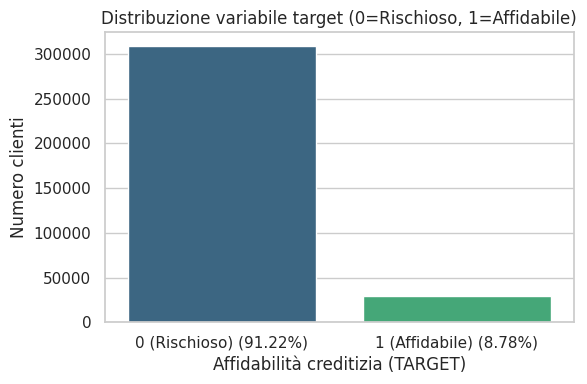

In [8]:
print("\nAnalisi variabile target 'TARGET':")
target_counts = df['TARGET'].value_counts()
target_perc = df['TARGET'].value_counts(normalize=True) * 100
print("Distribuzione in termini assoluti:")
print(target_counts)
print("\n Distribuzione in termini relativi (percentuali):")
print(target_perc)

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df, palette='viridis', hue='TARGET', legend=False)
plt.title('Distribuzione variabile target (0=Rischioso, 1=Affidabile)')
plt.xlabel('Affidabilità creditizia (TARGET)')
plt.ylabel('Numero clienti')
plt.xticks([0, 1], [f'0 (Rischioso) ({target_perc[0]:.2f}%)', f'1 (Affidabile) ({target_perc[1]:.2f}%)'])
plt.tight_layout()
plt.show()




Come già accennato, la variabile target è molto sbilanciata verso la classe 0 (clienti rischiosi). La classe 1 (clienti affidabili) rappresenta meno del 9%. La gestione dello sbilanciamento sarà cruciale e verrà espletata in fase di costruzione dei modelli.

###2.5 Analisi feature numeriche

Analisi DAYS_BIRTH:
count    338427.000000
mean         43.800720
std          11.480034
min          20.714579
25%          34.268309
50%          42.773443
75%          53.297741
max          72.925394
Name: AGE_YEARS, dtype: float64


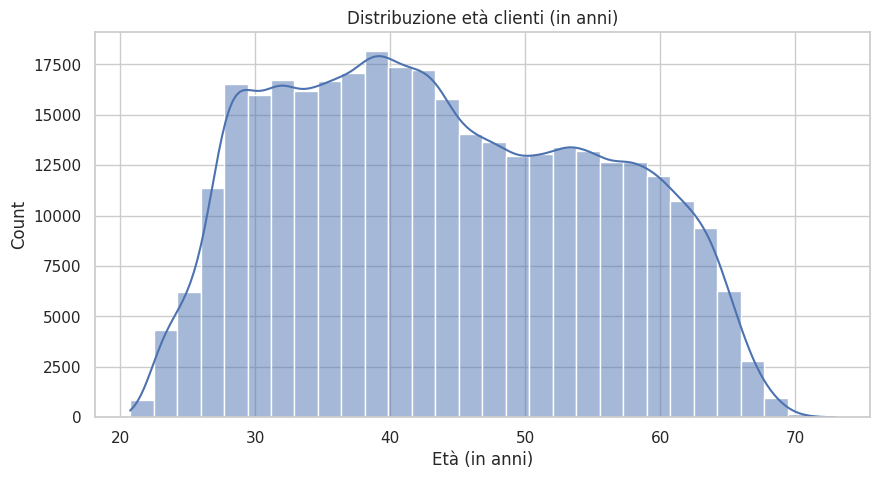


Analisi DAYS_EMPLOYED:
count    338427.000000
mean      60234.533869
std      138522.718590
min      -17973.000000
25%       -3116.000000
50%       -1483.000000
75%        -378.000000
max      396498.000000
Name: DAYS_EMPLOYED, dtype: float64


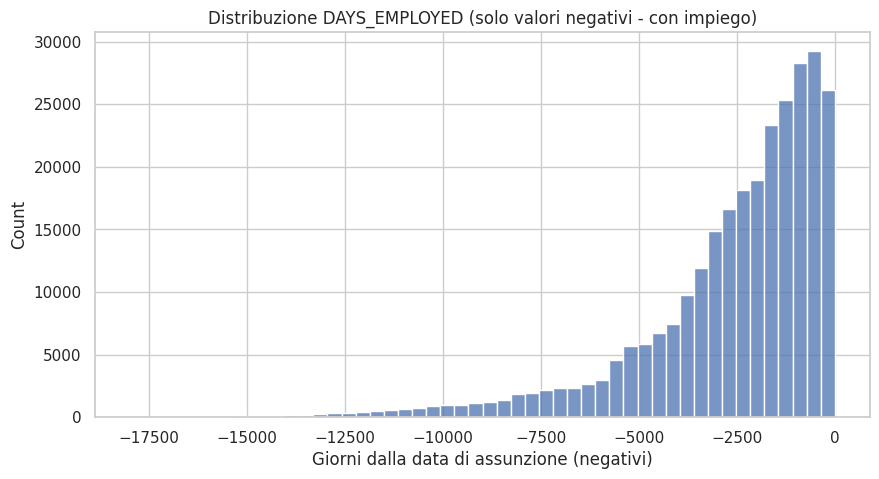

In [9]:
#analisi feature numeriche particolari (cronologiche)
print("Analisi DAYS_BIRTH:")
df['AGE_YEARS'] = abs(df['DAYS_BIRTH'])/365.25 #calcola età in anni e creazione nuova variabile
print(df['AGE_YEARS'].describe())
plt.figure(figsize=(10, 5))
sns.histplot(df['AGE_YEARS'], kde=True, bins=30)
plt.title('Distribuzione età clienti (in anni)')
plt.xlabel('Età (in anni)')
plt.show()

print("\nAnalisi DAYS_EMPLOYED:")
print(df['DAYS_EMPLOYED'].describe())
# Visualizziamo la distribuzione escludendo il possibile valore flag
plt.figure(figsize=(10, 5))
sns.histplot(df[df['DAYS_EMPLOYED'] < 0]['DAYS_EMPLOYED'], kde=False, bins=50)
plt.title('Distribuzione DAYS_EMPLOYED (solo valori negativi - con impiego)')
plt.xlabel('Giorni dalla data di assunzione (negativi)')
plt.show()

Numero di record con DAYS_EMPLOYED > 0 (potenzialmente disoccupati/ritirati): 57842
Valore massimo positivo: 396498.0


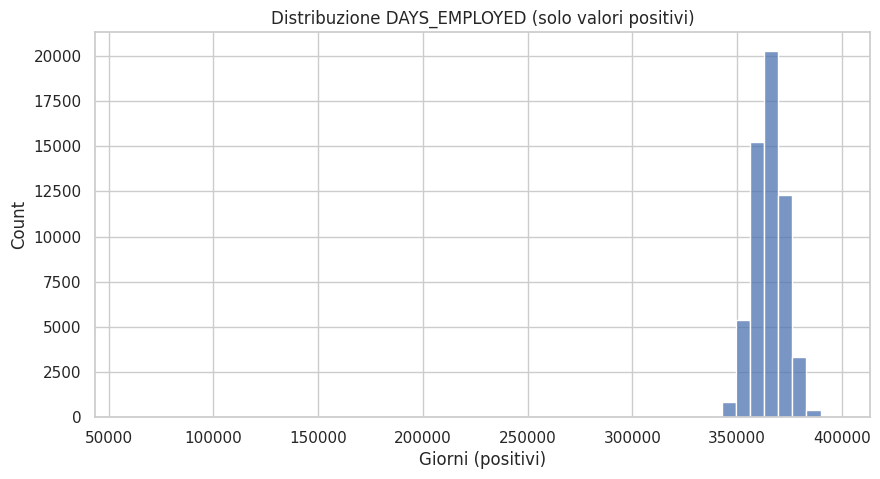

In [10]:
#ricerca valori positivi molto grandi
print(f"Numero di record con DAYS_EMPLOYED > 0 (potenzialmente disoccupati/ritirati): { (df['DAYS_EMPLOYED'] > 0).sum() }")
print(f"Valore massimo positivo: {df[df['DAYS_EMPLOYED'] > 0]['DAYS_EMPLOYED'].max()}")

plt.figure(figsize=(10, 5))
sns.histplot(df[df['DAYS_EMPLOYED'] > 0]['DAYS_EMPLOYED'], kde=False, bins=50)
plt.title('Distribuzione DAYS_EMPLOYED (solo valori positivi)')
plt.xlabel('Giorni (positivi)')
plt.show()

Nessuna delle due distribuzioni sopra risulta normale. Inoltre nel caso di DAYS_EMPLOYED si osservano diversi valori molto grandi come 365243 e sono spesso usati come flag per 'non applicabile' (disoccupato/ritirato).

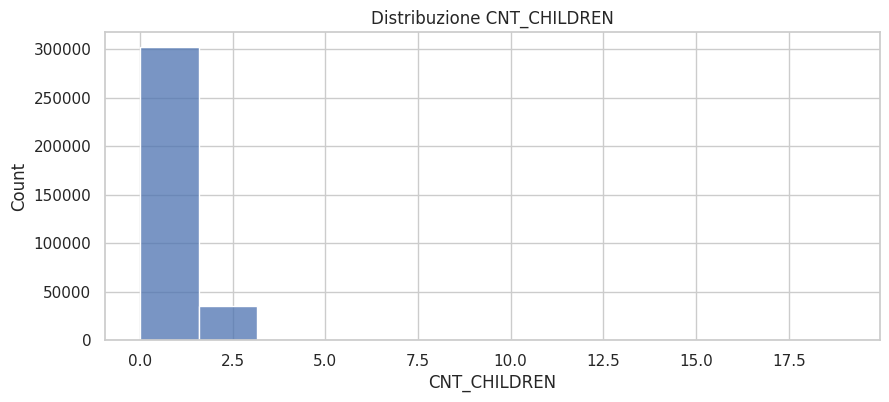

count    338427.000000
mean          0.428934
std           0.727990
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64
------------------------------


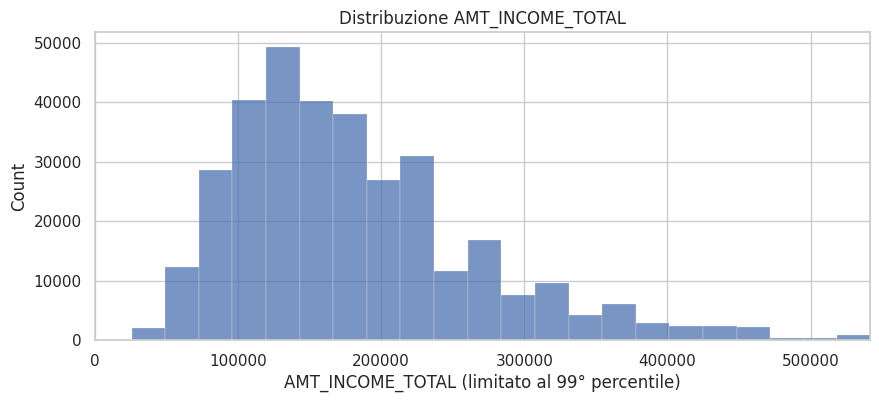

count    3.384270e+05
mean     1.876685e+05
std      1.107863e+05
min      2.554898e+04
25%      1.212299e+05
50%      1.628553e+05
75%      2.252082e+05
max      7.071016e+06
Name: AMT_INCOME_TOTAL, dtype: float64
------------------------------


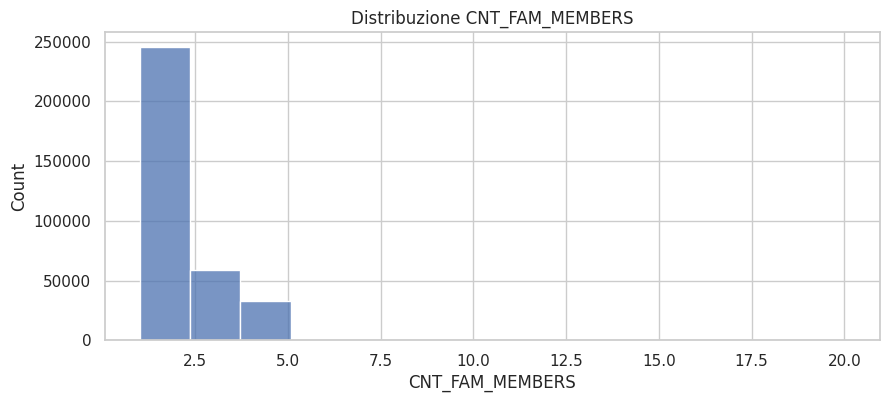

count    338427.000000
mean          2.197228
std           0.899569
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64
------------------------------


In [11]:
#analisi feature numeriche rimanenti
numerical_features = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'AGE_YEARS']
for col in ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS']:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=False, bins=min(300, df[col].nunique())) #limitazione dei bin per variabili discrete
    plt.title(f'Distribuzione {col}')
    #limite all'asse x per AMT_INCOME_TOTAL per migliorare leggibilità
    if col == 'AMT_INCOME_TOTAL':
        plt.xlim(0, df[col].quantile(0.99)) #viene mostrato fino al percentile 99
        plt.xlabel(f'{col} (limitato al 99° percentile)')
    else:
         plt.xlabel(col)
    plt.show()
    print(df[col].describe())
    print("-" * 30)

Anche le tre distribuzioni sopra non sono normali. Il reddito, come ben noto in letteratura si distribuisce come una Dagum.

###2.6 Analisi feature categoriche

Feature categoriche considerate: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'TARGET']


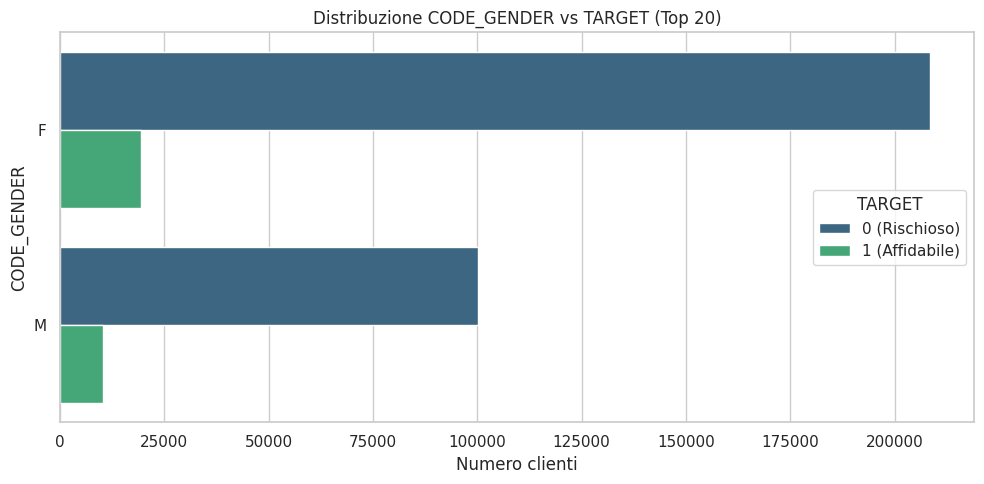


Conteggi per CODE_GENDER:
CODE_GENDER
F    227916
M    110511
Name: count, dtype: int64
------------------------------


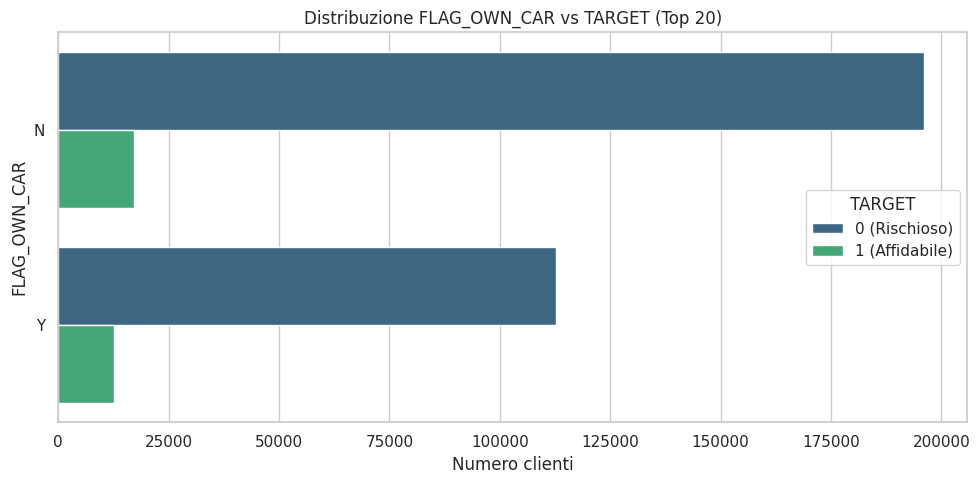


Conteggi per FLAG_OWN_CAR:
FLAG_OWN_CAR
N    213196
Y    125231
Name: count, dtype: int64
------------------------------


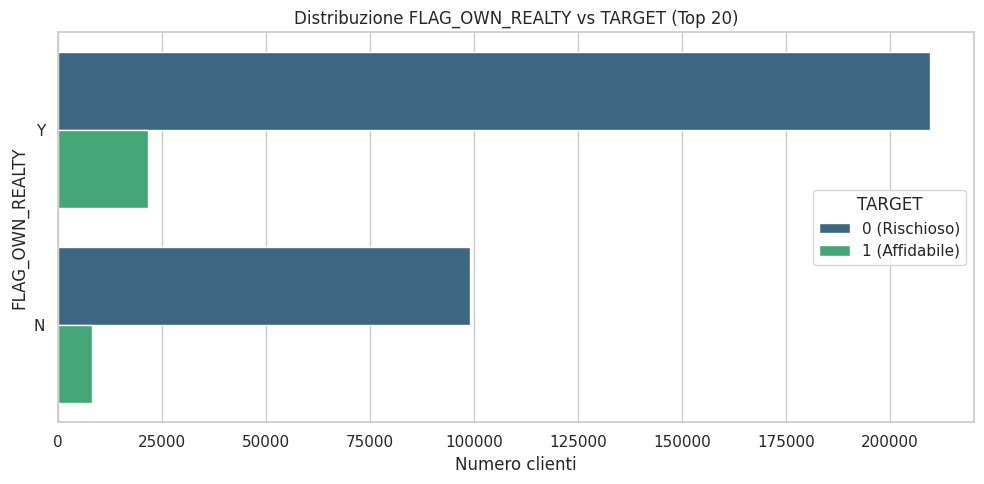


Conteggi per FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    231307
N    107120
Name: count, dtype: int64
------------------------------


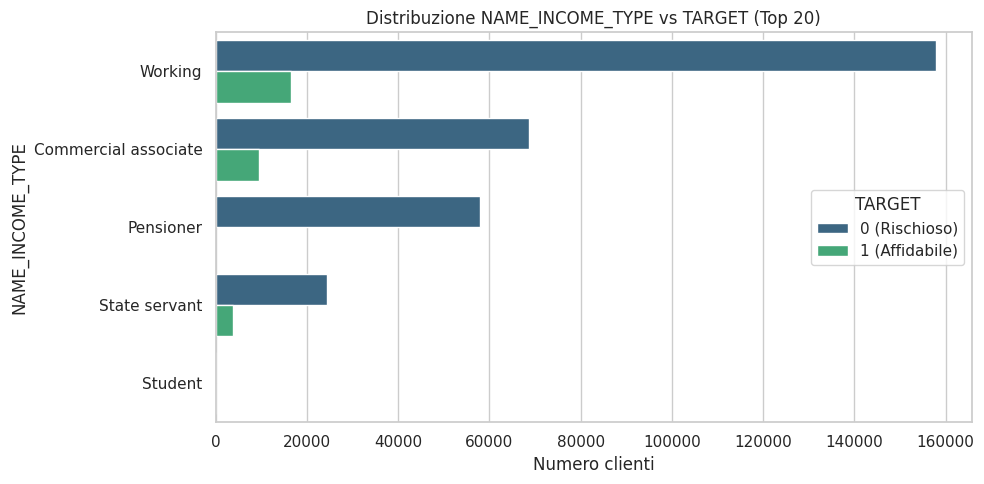


Conteggi per NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 174366
Commercial associate     78090
Pensioner                57841
State servant            28113
Student                     17
Name: count, dtype: int64
------------------------------


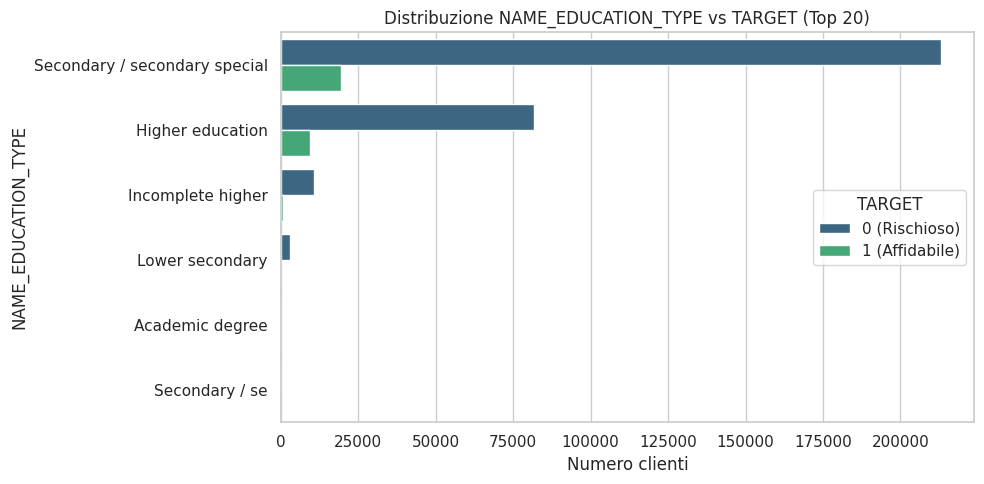


Conteggi per NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special    232568
Higher education                  91062
Incomplete higher                 11387
Lower secondary                    3177
Academic degree                     232
Secondary / se                        1
Name: count, dtype: int64
------------------------------


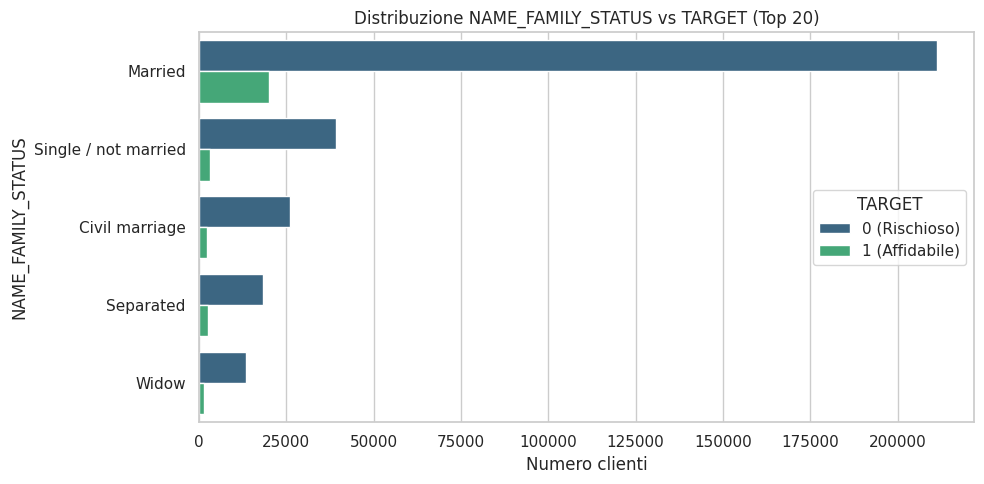


Conteggi per NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Married                 231495
Single / not married     42509
Civil marriage           28516
Separated                20809
Widow                    15098
Name: count, dtype: int64
------------------------------


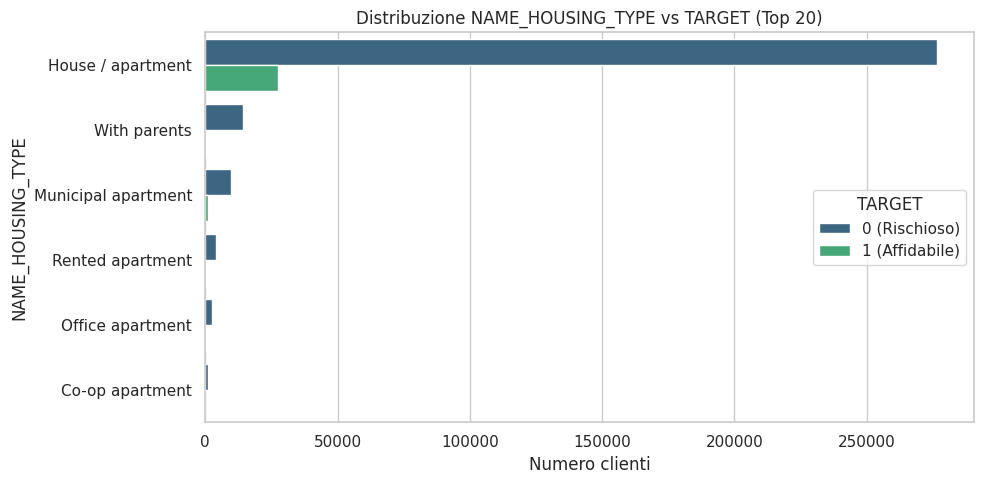


Conteggi per NAME_HOUSING_TYPE:
NAME_HOUSING_TYPE
House / apartment      304411
With parents            14625
Municipal apartment     10819
Rented apartment         4442
Office apartment         2968
Co-op apartment          1162
Name: count, dtype: int64
------------------------------


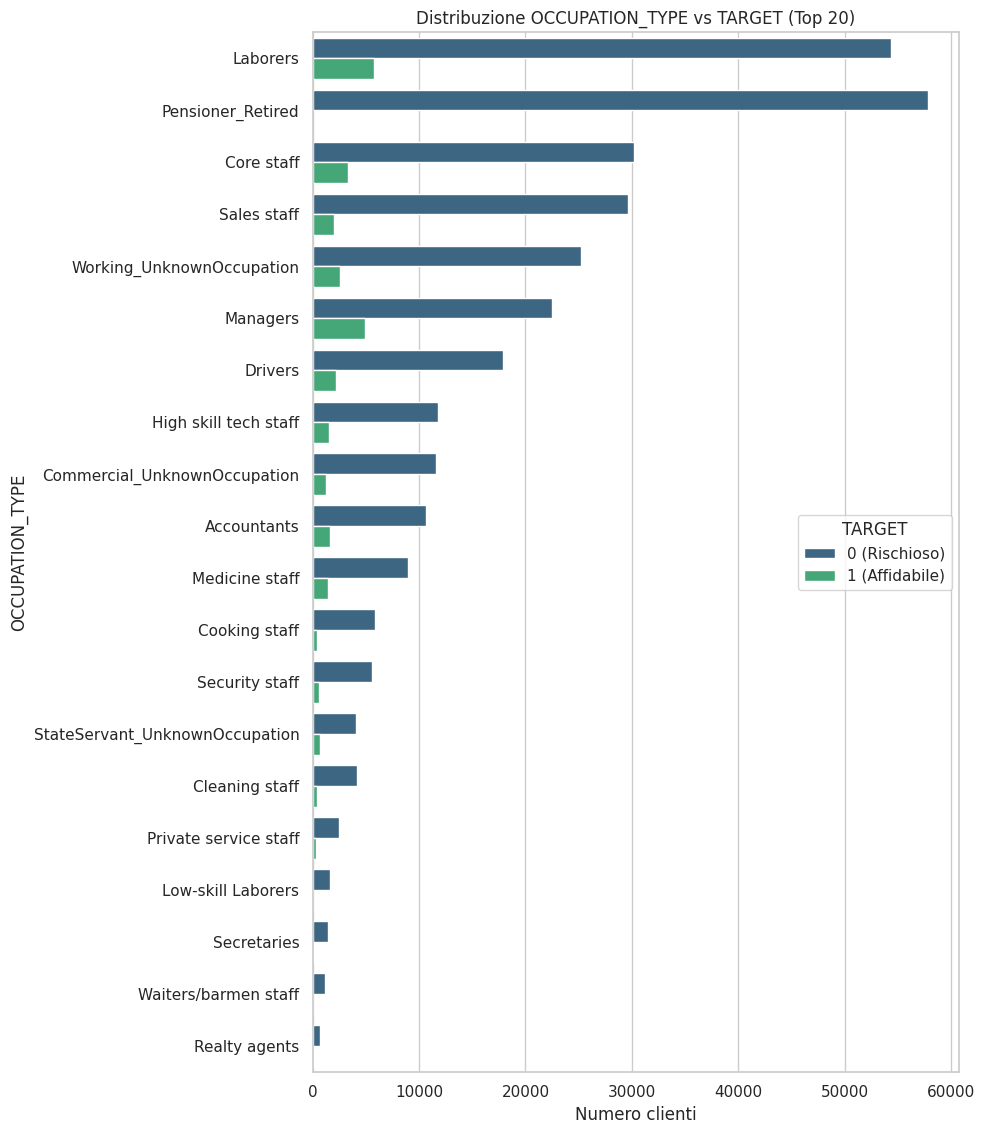


Conteggi per OCCUPATION_TYPE:
OCCUPATION_TYPE
Laborers                          60146
Pensioner_Retired                 57841
Core staff                        33527
Sales staff                       31652
Working_UnknownOccupation         27784
Managers                          27384
Drivers                           20020
High skill tech staff             13399
Commercial_UnknownOccupation      12927
Accountants                       12281
Medicine staff                    10438
Cooking staff                      6248
Security staff                     6218
StateServant_UnknownOccupation     4785
Cleaning staff                     4594
Private service staff              2787
Low-skill Laborers                 1714
Secretaries                        1577
Waiters/barmen staff               1245
Realty agents                       852
HR staff                            567
IT staff                            436
Student_Unemployed/Other              5
Name: count, dtype: int64
-------

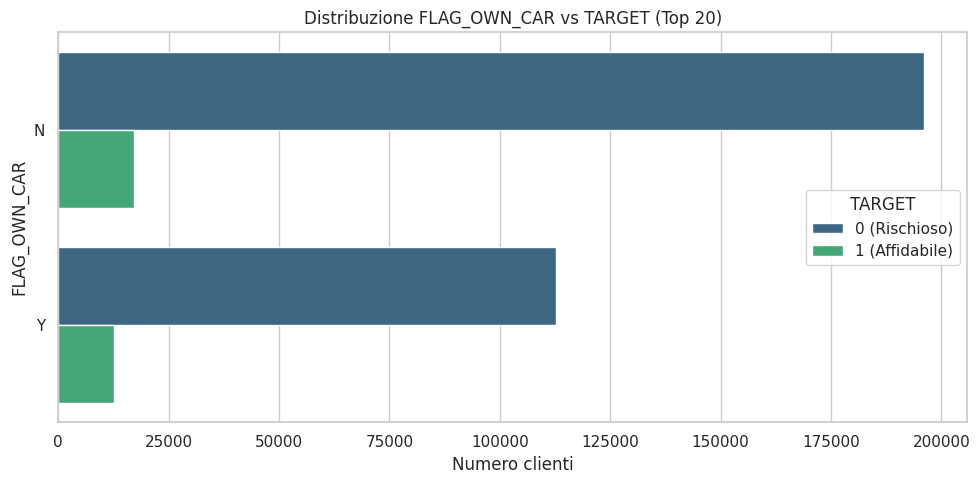


Conteggi per FLAG_OWN_CAR:
FLAG_OWN_CAR
N    213196
Y    125231
Name: count, dtype: int64
------------------------------


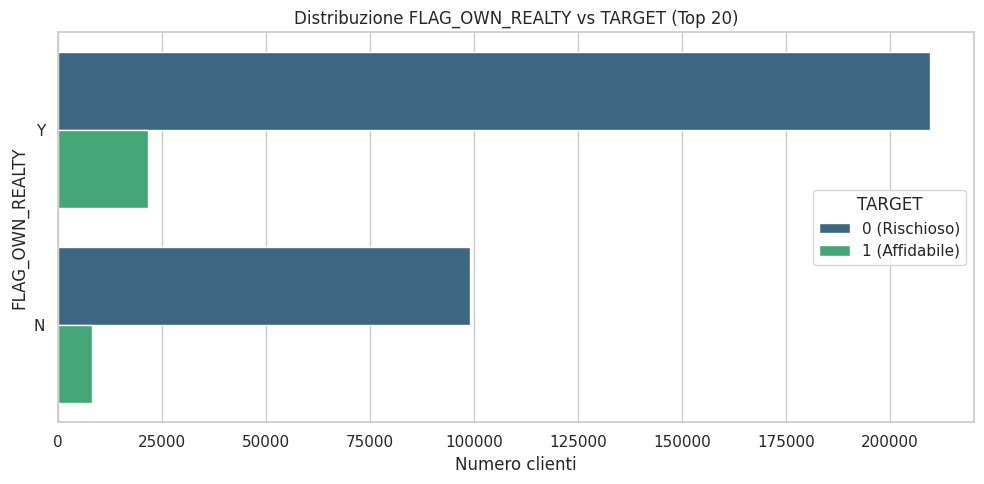


Conteggi per FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    231307
N    107120
Name: count, dtype: int64
------------------------------


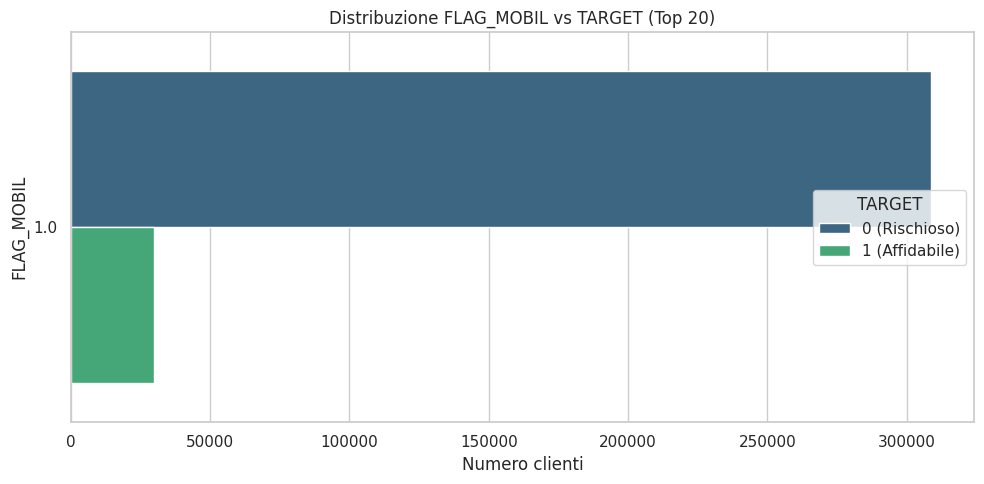


Conteggi per FLAG_MOBIL:
FLAG_MOBIL
1.0    338427
Name: count, dtype: int64
------------------------------


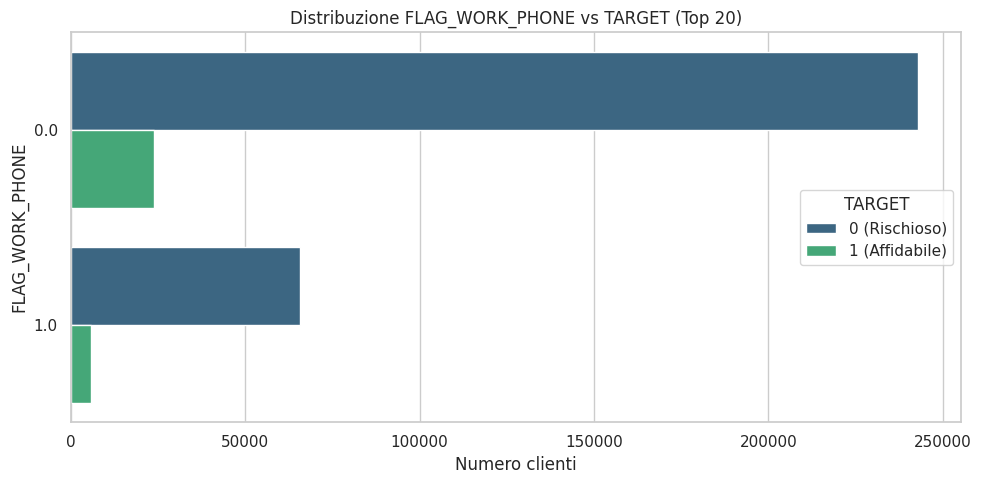


Conteggi per FLAG_WORK_PHONE:
FLAG_WORK_PHONE
0.0    266891
1.0     71536
Name: count, dtype: int64
------------------------------


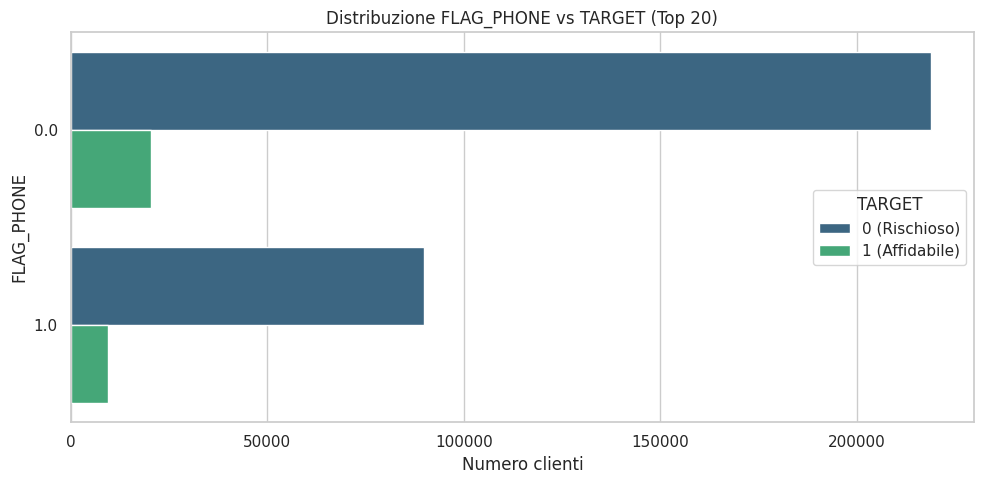


Conteggi per FLAG_PHONE:
FLAG_PHONE
0.0    239166
1.0     99261
Name: count, dtype: int64
------------------------------


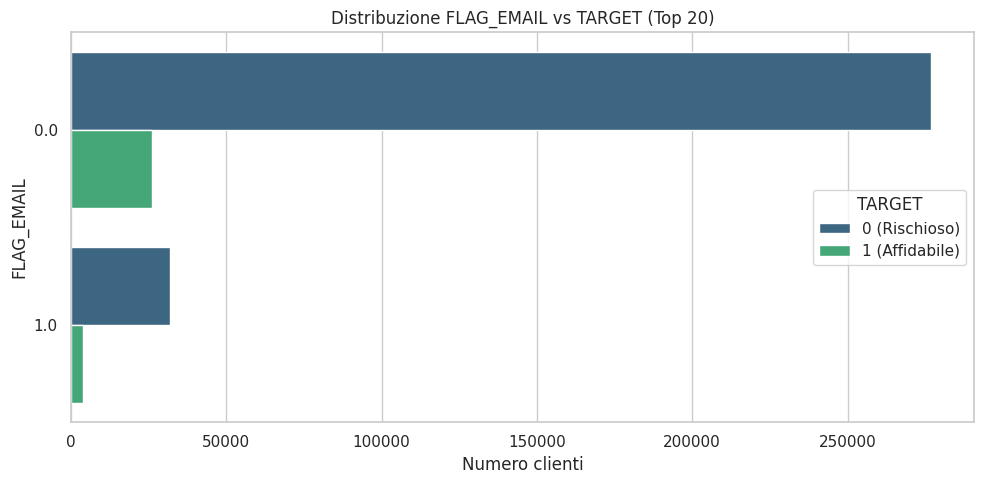


Conteggi per FLAG_EMAIL:
FLAG_EMAIL
0.0    302831
1.0     35596
Name: count, dtype: int64
------------------------------


In [12]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.extend(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'TARGET'])
print(f"Feature categoriche considerate: {categorical_features}")

for col in categorical_features:
    if col == 'TARGET': continue #già analizzata
    plt.figure(figsize=(10, max(5, df[col].nunique() * 0.5))) #altezza dinamica per leggibilità
    order = df[col].value_counts().index[:20] #mostra le 20 categorie più frequenti
    sns.countplot(y=col, data=df, order=order, palette='viridis', hue='TARGET')
    plt.title(f'Distribuzione {col} vs TARGET (Top 20)') #si tiene conto anche della target
    plt.xlabel('Numero clienti')
    plt.ylabel(col)
    plt.legend(title='TARGET', loc='center right', labels=['0 (Rischioso)', '1 (Affidabile)'])
    plt.tight_layout()
    plt.show()
    print(f"\nConteggi per {col}:")
    print(df[col].value_counts())
    print("-" * 30)

Di tutte le distribuzioni delle variabili categoriche si segnala che FLAG_MOBIL assume solo una modalità: 1. Quindi tale feature non è particolarmente informativa quindi nel seguito verrà rimossa. In tutte le altre si nota il costante sbilanciamento della variabile target.

#3 Preprocessing dei dati

In questa sezione viene mostrato il preprocessing dei dati con le seguenti strategie:<br>
* Dalla feature DAYS_BIRTH viene costruita AGE_YEARS che è più informativa e di facile interpretazione con valori esclusivamente positivi.
* I valori positivi di DAYS_EMPLOYED, come già accennato precedentemente, vengono trattati come se fossero anomali.
* Sono rimosse le seguenti features: DAYS_BIRTH, DAYS_EMPLOYED, FLAG_MOBIL.
* Usando i valori negativi di DAYS_EMPLOYED viene costruita la variabile YEARS_EMPLOYED per gli stessi motivi di AGE_YEARS.
* Vengono costruite due pipeline per gestire feature numeriche e categoriche. Alle features numeriche viene applicata l'imputazione della mediana per i dati mancanti e poi lo standard scaler, invece per le features categoriche viene usata l'imputazione della moda per i dati mancanti e poi il one hot encoder.

In [13]:
#copia del dataset per il preprocessing
df_processed = df.copy()

#Gestione feature cronologiche
print("\n>>>>>Trasformazione feature cronologiche...")
#età in anni (già calcolata in EDA, assicuriamoci sia nel df_processed)
if 'AGE_YEARS' not in df_processed.columns:
     df_processed['AGE_YEARS'] = abs(df_processed['DAYS_BIRTH']) / 365.25
     print("Feature 'AGE_YEARS' aggiunta al dataset.")

#gestione DAYS_EMPLOYED
#valori positivi enormi (es. 365243) indicano stati come non occupato/ritirato. quindi verranno trattati come nan inizialmente.
df_processed['DAYS_EMPLOYED_ANOMALY'] = (df_processed['DAYS_EMPLOYED'] > 0).astype(int) #anomalia/non impiegato
df_processed['DAYS_EMPLOYED'] = df_processed['DAYS_EMPLOYED'].replace(365243, np.nan) # Sostituisci valore anomalo
#conversione giorni di impiego negativi in anni positivi
df_processed['YEARS_EMPLOYED'] = abs(df_processed[df_processed['DAYS_EMPLOYED'] < 0]['DAYS_EMPLOYED']) / 365.25
# imputazione dei nan in YEARS_EMPLOYED (che ora includono gli originariamente positivi e i nuovi nan) con 0 assumendo 0 anni di impiego per chi non è impiegato o ha dati anomali
df_processed['YEARS_EMPLOYED'] = df_processed['YEARS_EMPLOYED'].fillna(0)
print("Feature 'AGE_YEARS', 'DAYS_EMPLOYED_ANOMALY', 'YEARS_EMPLOYED' create/gestite.")

#rimozione colonne non necessarie
print("\n>>>>>Rimozione colonne originali o non necessarie...")
columns_to_drop = ['DAYS_BIRTH', 'DAYS_EMPLOYED'] #id già rimosso all'inizio dell'import del dataset
#rimozione FLAG_MOBIL che è costante e non apporta informazione
if 'FLAG_MOBIL' in df_processed.columns and df_processed['FLAG_MOBIL'].nunique() == 1:
    print("Rimozione colonna 'FLAG_MOBIL' (valore costante).")
    columns_to_drop.append('FLAG_MOBIL')
df_processed = df_processed.drop(columns=columns_to_drop)
print(f"Colonne rimosse: {columns_to_drop}")

#definizione feature numeriche e categoriche per il transformer
#aggiornamento liste dopo le trasformazioni precedenti
numerical_features = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED']
#tutte le altre sono considerate categoriche (oggetti o binarie)
#esclusione 'TARGET'
all_columns = df_processed.columns.tolist()
categorical_features = [col for col in all_columns if col not in numerical_features and col != 'TARGET']
print(f"\n>>>>>Feature Numeriche Identificate: {numerical_features}")
print(f"\n>>>>>Feature Categoriche Identificate: {categorical_features}")

#creazione pipeline di preprocessing
#SimpleImputer per gestire eventuali NaN residui o futuri nelle numeriche e OneHotEncoder per le categoriche.

# pipeline per feature numeriche: imputazione (mediana) + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) #scala
])

#pipeline per feature categoriche: imputazione (costante 'Mancante') + OneHotEncoding
#OSSERVAZIONE: già gestito OCCUPATION_TYPE, ma l'imputer qui gestisce altre eventuali mancanze future.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Mancante')), #imputa con 'Mancante'
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # OHE, handle_unknown, output denso
])

#creazione ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' #mantiene colonne non specificate
)

print("\n>>>>>Preprocessor definito (imputazione + scaling per numeriche, imputazione + OHE per categoriche).")

#separazione features (X) e target (y) dal dataset processato
X = df_processed.drop('TARGET', axis=1)
y = df_processed['TARGET']
print(f"\nForma finale di X: {X.shape}")
print(f"Forma finale di y: {y.shape}")


>>>>>Trasformazione feature cronologiche...
Feature 'AGE_YEARS', 'DAYS_EMPLOYED_ANOMALY', 'YEARS_EMPLOYED' create/gestite.

>>>>>Rimozione colonne originali o non necessarie...
Rimozione colonna 'FLAG_MOBIL' (valore costante).
Colonne rimosse: ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL']

>>>>>Feature Numeriche Identificate: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED']

>>>>>Feature Categoriche Identificate: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'DAYS_EMPLOYED_ANOMALY']

>>>>>Preprocessor definito (imputazione + scaling per numeriche, imputazione + OHE per categoriche).

Forma finale di X: (338427, 17)
Forma finale di y: (338427,)


#4 Divisione del dataset in training e test set

In questa sezione viene mostrata la costruzione del training e test sets mantenendo comunque una stratificazione bilanciata della variabile target nei due sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       #30% per il test set
    random_state=RANDOM_STATE,
    stratify=y            #per mantenere proporzione della target (molto sbilanciata)
)

print(f"Dimensioni training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Dimensioni test set: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"\nDistribuzione 'TARGET' nel training set:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribuzione 'TARGET' nel test set:\n{y_test.value_counts(normalize=True)}")

Dimensioni training set: X_train=(236898, 17), y_train=(236898,)
Dimensioni test set: X_test=(101529, 17), y_test=(101529,)

Distribuzione 'TARGET' nel training set:
TARGET
0    0.912177
1    0.087823
Name: proportion, dtype: float64

Distribuzione 'TARGET' nel test set:
TARGET
0    0.912173
1    0.087827
Name: proportion, dtype: float64


#5 Modelli

In questa sezione viene mostrata la costruzione di diversi modelli (dato l'obiettivo di prevedere una variabile target binaria): logistic regression, decision tree, random forest, SVM, naive bayes, multilayer perceptron, lightGBM, XGBoost.<br>
In ogni modello verrà gestito lo sbilanciamento della variabile target come segue: quando possibile viene usato il parametro class_weight='balanced', se invece non è possibile (come ad esempio nel MLP) allora viene usata la tecnica RUS.<br>
Per quano riguarda il possibile overfitting vengono impostati parametri che potrebbero eludere tale problema e che fanno convergere le learning curve verso un valore comune.<br>
Per ogni modello sono mostrate le principali metriche di valutazione e la learning curve.
<br>
<br>


###5.1 Modello 1: Logistic regression

In [15]:
#dizionario per salvare i risultati di ogni modello
model_results = {}

#considerato lo sbilanciamento è impostato class_weight='balanced' dove possibile.
#se non possibile verranno implementate SMOTE o RUS (in questo progetto viene scelto RUS).

#Modello 1: Logistic Regression
print(">>>>>Modello 1: Logistic Regression")
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, solver='liblinear', max_iter=1000))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
model_results['Logistic Regression'] = {'pred': y_pred_lr, 'prob': y_prob_lr, 'pipeline': pipeline_lr}
print(">>Valutazione Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lr):.4f}\n")

>>>>>Modello 1: Logistic Regression
>>Valutazione Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     92612
           1       0.32      0.89      0.47      8917

    accuracy                           0.83    101529
   macro avg       0.65      0.85      0.68    101529
weighted avg       0.93      0.83      0.86    101529

ROC AUC: 0.9190



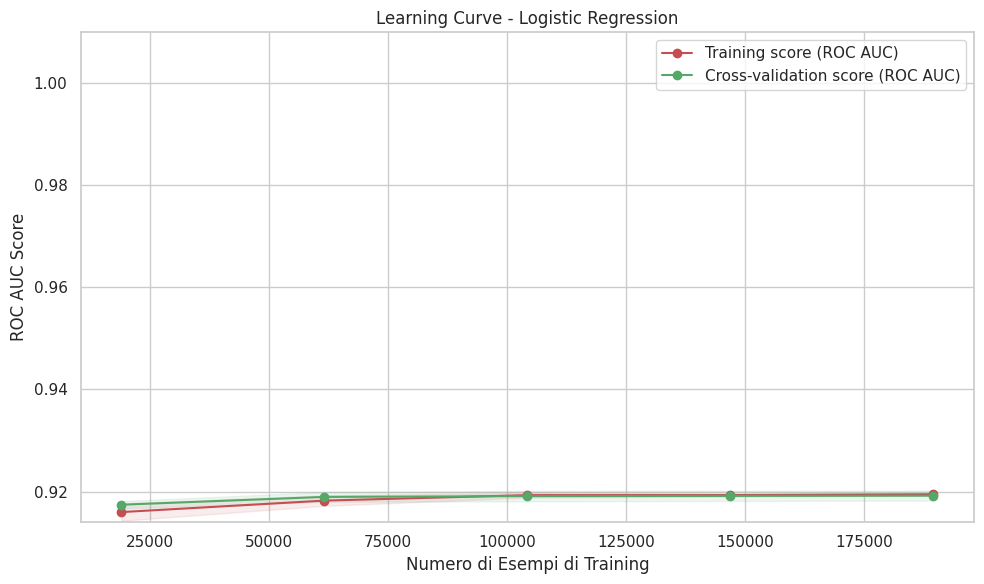


Punteggio medio finale di Cross-Validation (con 189518 esempi) per Logistic Regression: 0.9192


In [16]:
#Learning Curve
train_sizes_proportions = np.linspace(0.1, 1.0, 5)

train_sizes_abs, train_scores, validation_scores = learning_curve(
    estimator=pipeline_lr,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi per ogni dimensione
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                  train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, validation_scores_mean - validation_scores_std,
                  validation_scores_mean + validation_scores_std, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs, validation_scores_mean, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs[-1]} esempi) per Logistic Regression: {validation_scores_mean[-1]:.4f}")

###5.2 Modello 2: Decision Tree

In [17]:
#Modello 2: Decision Tree
#l'albero viene addestrato con profondità limitata per interpretabilità e controllo overfitting tramite max_depth e min_samples_leaf
print(">>>>>Modello 2: Decision Tree")
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE, max_depth=6, min_samples_leaf=30)) #bassa profondità per overfitting
])
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]
model_results['Decision Tree'] = {'pred': y_pred_dt, 'prob': y_prob_dt, 'pipeline': pipeline_dt}
print(">>Valutazione Decision Tree:")
print(classification_report(y_test, y_pred_dt))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_dt):.4f}\n")

>>>>>Modello 2: Decision Tree
>>Valutazione Decision Tree:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     92612
           1       0.63      0.99      0.77      8917

    accuracy                           0.95    101529
   macro avg       0.81      0.97      0.87    101529
weighted avg       0.97      0.95      0.95    101529

ROC AUC: 0.9760



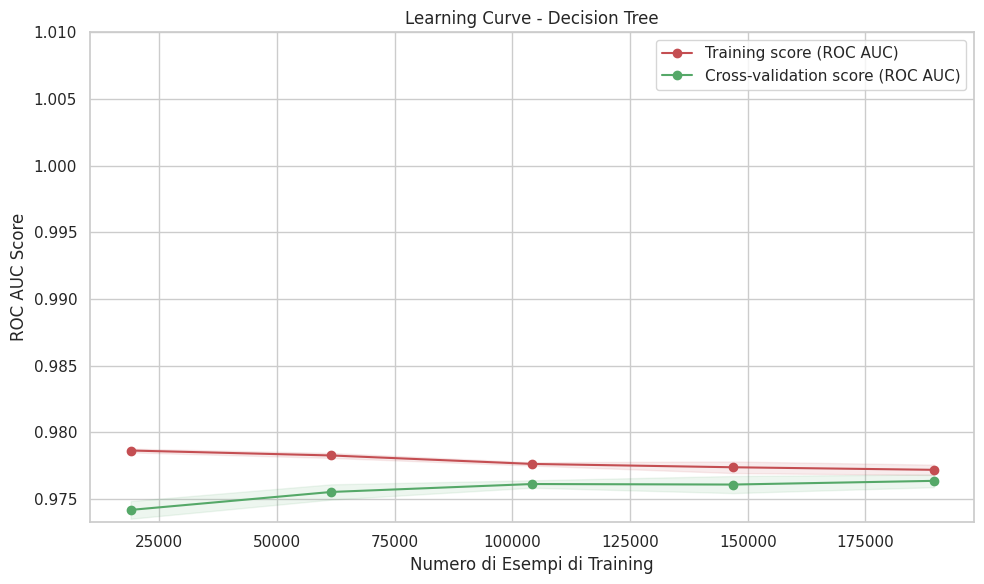


Punteggio medio finale di Cross-Validation (con 189518 esempi) per Decision Tree: 0.9764


In [18]:
#Learning Curve
train_sizes_proportions_dt = np.linspace(0.1, 1.0, 5)

train_sizes_abs_dt, train_scores_dt, validation_scores_dt = learning_curve(
    estimator=pipeline_dt,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi per ogni dimensione
train_scores_mean_dt = np.mean(train_scores_dt, axis=1)
train_scores_std_dt = np.std(train_scores_dt, axis=1)
validation_scores_mean_dt = np.mean(validation_scores_dt, axis=1)
validation_scores_std_dt = np.std(validation_scores_dt, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs_dt, train_scores_mean_dt - train_scores_std_dt,
                  train_scores_mean_dt + train_scores_std_dt, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs_dt, validation_scores_mean_dt - validation_scores_std_dt,
                  validation_scores_mean_dt + validation_scores_std_dt, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs_dt, train_scores_mean_dt, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs_dt, validation_scores_mean_dt, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - Decision Tree")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_dt[-1]} esempi) per Decision Tree: {validation_scores_mean_dt[-1]:.4f}")

###5.3 Modello 3: Random Forest

In [19]:
#Modello 3: Random Forest
#è implementata la stessa strategia del modello 2
print(">>>>>Modello 3: Random Forest")
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=100, max_depth=5, min_samples_leaf=10, n_jobs=-1))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]
model_results['Random Forest'] = {'pred': y_pred_rf, 'prob': y_prob_rf, 'pipeline': pipeline_rf}
print(">>Valutazione Random Forest:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}\n")

>>>>>Modello 3: Random Forest
>>Valutazione Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     92612
           1       0.63      0.99      0.77      8917

    accuracy                           0.95    101529
   macro avg       0.82      0.97      0.87    101529
weighted avg       0.97      0.95      0.95    101529

ROC AUC: 0.9753



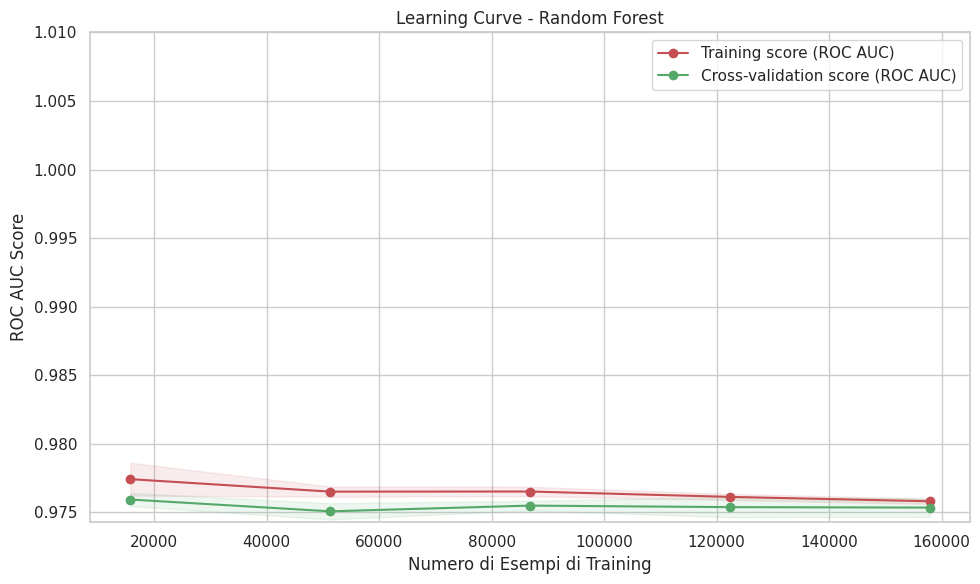


Punteggio medio finale di Cross-Validation (con 157932 esempi) per Random Forest: 0.9754


In [20]:
#Learning Curve
train_sizes_proportions_rf = np.linspace(0.1, 1.0, 5)

train_sizes_abs_rf, train_scores_rf, validation_scores_rf = learning_curve(
    estimator=pipeline_rf,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions_rf,
    cv=3, #inferiore ai precedenti perchè richiederebbe molto tempo
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi per ogni dimensione
train_scores_mean_rf = np.mean(train_scores_rf, axis=1)
train_scores_std_rf = np.std(train_scores_rf, axis=1)
validation_scores_mean_rf = np.mean(validation_scores_rf, axis=1)
validation_scores_std_rf = np.std(validation_scores_rf, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs_rf, train_scores_mean_rf - train_scores_std_rf,
                  train_scores_mean_rf + train_scores_std_rf, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs_rf, validation_scores_mean_rf - validation_scores_std_rf,
                  validation_scores_mean_rf + validation_scores_std_rf, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs_rf, train_scores_mean_rf, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs_rf, validation_scores_mean_rf, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - Random Forest")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_rf[-1]} esempi) per Random Forest: {validation_scores_mean_rf[-1]:.4f}")

###5.4 Modello (omesso): SVM/SVC

In [21]:
#Modello 4: SVM/SVC
#OMESSO PERCHÈ L'ESECUZIONE DI QUESTA E DELLA PROSSIMA CELLA RICHIEDE MOLTO TEMPO

#print(">>>>>Modello 4: SVM/SVC")
#pipeline_svc = Pipeline(steps=[
#    ('preprocessor', preprocessor),
#    ('classifier', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=RANDOM_STATE))
#])
#pipeline_svc.fit(X_train, y_train)
#y_pred_svc = pipeline_svc.predict(X_test)
#y_prob_svc = pipeline_svc.predict_proba(X_test)[:, 1]
#model_results['SVM/SVC (Linear)'] = {'pred': y_pred_svc, 'prob': y_prob_svc, 'pipeline': pipeline_svc}
#print(">>Valutazione SVM/SVC (Linear):")
#print(classification_report(y_test, y_pred_svc, zero_division=0))
#print(f"ROC AUC: {roc_auc_score(y_test, y_prob_svc):.4f}\n")

In [22]:
#train_sizes_proportions_svc = np.linspace(0.1, 1.0, 5)

#train_sizes_abs_svc, train_scores_svc, validation_scores_svc = learning_curve(
#    estimator=pipeline_svc,
#    X=X_train,
#    y=y_train,
#    train_sizes=train_sizes_proportions_svc,
#    cv=3,
#    scoring='roc_auc',
#    n_jobs=-1,
#    random_state=RANDOM_STATE
#)

#calcolo media e deviazione standard
#train_scores_mean_svc = np.mean(train_scores_svc, axis=1)
#train_scores_std_svc = np.std(train_scores_svc, axis=1)
#validation_scores_mean_svc = np.mean(validation_scores_svc, axis=1)
#validation_scores_std_svc = np.std(validation_scores_svc, axis=1)

#plt.figure(figsize=(10, 6))

#area deviazione standard
#plt.fill_between(train_sizes_abs_svc, train_scores_mean_svc - train_scores_std_svc,
#                  train_scores_mean_svc + train_scores_std_svc, alpha=0.1, color="r")
#plt.fill_between(train_sizes_abs_svc, validation_scores_mean_svc - validation_scores_std_svc,
#                  validation_scores_mean_svc + validation_scores_std_svc, alpha=0.1, color="g")

#curve delle medie
#plt.plot(train_sizes_abs_svc, train_scores_mean_svc, 'o-', color="r",
#          label="Training score (ROC AUC)")
#plt.plot(train_sizes_abs_svc, validation_scores_mean_svc, 'o-', color="g",
#          label="Cross-validation score (ROC AUC)")

#plt.title("Learning Curve - SVM/SVC (Linear)")
#plt.xlabel("Numero di Esempi di Training")
#plt.ylabel("ROC AUC Score")
#plt.legend(loc="best")
#plt.grid(True)
#plt.ylim(None, 1.01)
#plt.tight_layout()
#plt.show()

#punteggio
#print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_svc[-1]} esempi) per SVM/SVC (Linear): {validation_scores_mean_svc[-1]:.4f}")


###5.5 Modello 4: Naive Bayes

In [23]:
#Modello 5: Naive Bayes
print(">>>>>Modello 5: Naive Bayes (GaussianNB) con RUS")

#pipeline da imblearn per integrare correttamente il campionatore.
pipeline_nb_rus = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)), #RUS per gestione sbilanciamento
    ('classifier', GaussianNB())
])

pipeline_nb_rus.fit(X_train, y_train)

y_pred_nb_rus = pipeline_nb_rus.predict(X_test)
y_prob_nb_rus = pipeline_nb_rus.predict_proba(X_test)[:, 1]

#salvataggio dei risultati
model_results['Naive Bayes (Gaussian + RUS)'] = {
    'pred': y_pred_nb_rus,
    'prob': y_prob_nb_rus,
    'pipeline': pipeline_nb_rus
}

print(">>Valutazione Naive Bayes (Gaussian + RUS):")
print(classification_report(y_test, y_pred_nb_rus, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_nb_rus):.4f}\n")


>>>>>Modello 5: Naive Bayes (GaussianNB) con RUS
>>Valutazione Naive Bayes (Gaussian + RUS):
              precision    recall  f1-score   support

           0       0.99      0.26      0.42     92612
           1       0.11      0.97      0.20      8917

    accuracy                           0.33    101529
   macro avg       0.55      0.62      0.31    101529
weighted avg       0.91      0.33      0.40    101529

ROC AUC: 0.8034



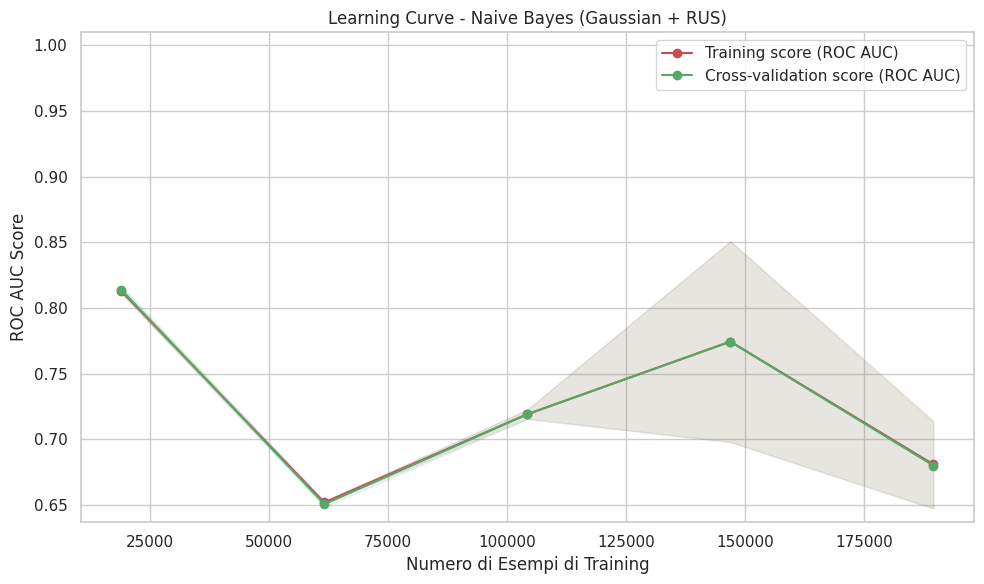


Punteggio medio finale di Cross-Validation (con 189518 esempi) per Naive Bayes (Gaussian + RUS): 0.6800


In [24]:
#Learning Curve
train_sizes_proportions_nb_rus = np.linspace(0.1, 1.0, 5)

train_sizes_abs_nb_rus, train_scores_nb_rus, validation_scores_nb_rus = learning_curve(
    estimator=pipeline_nb_rus,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions_nb_rus,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi
train_scores_mean_nb_rus = np.mean(train_scores_nb_rus, axis=1)
train_scores_std_nb_rus = np.std(train_scores_nb_rus, axis=1)
validation_scores_mean_nb_rus = np.mean(validation_scores_nb_rus, axis=1)
validation_scores_std_nb_rus = np.std(validation_scores_nb_rus, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs_nb_rus, train_scores_mean_nb_rus - train_scores_std_nb_rus,
                  train_scores_mean_nb_rus + train_scores_std_nb_rus, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs_nb_rus, validation_scores_mean_nb_rus - validation_scores_std_nb_rus,
                  validation_scores_mean_nb_rus + validation_scores_std_nb_rus, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs_nb_rus, train_scores_mean_nb_rus, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs_nb_rus, validation_scores_mean_nb_rus, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - Naive Bayes (Gaussian + RUS)")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_nb_rus[-1]} esempi) per Naive Bayes (Gaussian + RUS): {validation_scores_mean_nb_rus[-1]:.4f}")


###5.6 Modello 5: Multilayer Perceptron

In [25]:
#Modello 6: Multilayer Perceptron (MLP) con RandomUnderSampler (RUS)
print(">>>>>Modello 6: MLP con RUS")
#MLP non ha class_weight
#Early stopping aiuta a prevenire overfitting e a ridurre il tempo di training
#sparse_output=False in OneHotEncoder è spesso necessario per MLP se si usa OHE nel preprocessor

pipeline_mlp_rus = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)), #RUS
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', alpha=0.01, #regolarizzazione L2 dopo diverse prove
                                 max_iter=1000, random_state=RANDOM_STATE,
                                 early_stopping=True, n_iter_no_change=10, tol=1e-4,
                                 validation_fraction=0.1))
])

pipeline_mlp_rus.fit(X_train, y_train)

y_pred_mlp_rus = pipeline_mlp_rus.predict(X_test)
y_prob_mlp_rus = pipeline_mlp_rus.predict_proba(X_test)[:, 1]

#salvataggio dei risultati
model_results['MLP Classifier + RUS'] = {
    'pred': y_pred_mlp_rus,
    'prob': y_prob_mlp_rus,
    'pipeline': pipeline_mlp_rus
}

print(">>Valutazione MLP Classifier + RUS:")
print(classification_report(y_test, y_pred_mlp_rus, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_mlp_rus):.4f}\n")

>>>>>Modello 6: MLP con RUS
>>Valutazione MLP Classifier + RUS:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     92612
           1       0.63      0.99      0.77      8917

    accuracy                           0.95    101529
   macro avg       0.81      0.97      0.87    101529
weighted avg       0.97      0.95      0.95    101529

ROC AUC: 0.9779



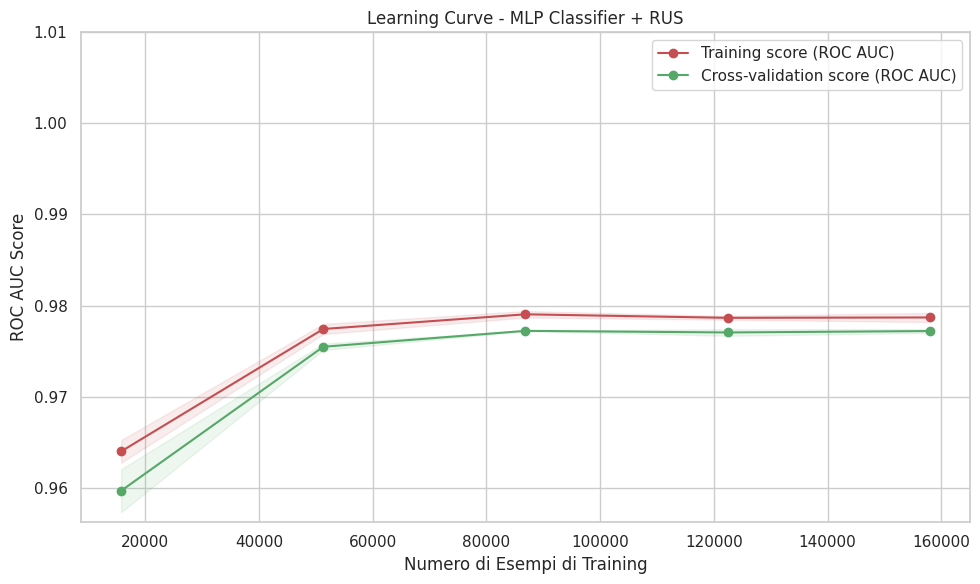


Punteggio medio finale di Cross-Validation (con 157932 esempi) per MLP Classifier + RUS: 0.9772


In [26]:
#Learning Curve
train_sizes_proportions_mlp_rus = np.linspace(0.1, 1.0, 5)

train_sizes_abs_mlp_rus, train_scores_mlp_rus, validation_scores_mlp_rus = learning_curve(
    estimator=pipeline_mlp_rus,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions_mlp_rus,
    cv=3, #per ridurre il tempo di esecuzione
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi
train_scores_mean_mlp_rus = np.mean(train_scores_mlp_rus, axis=1)
train_scores_std_mlp_rus = np.std(train_scores_mlp_rus, axis=1)
validation_scores_mean_mlp_rus = np.mean(validation_scores_mlp_rus, axis=1)
validation_scores_std_mlp_rus = np.std(validation_scores_mlp_rus, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs_mlp_rus, train_scores_mean_mlp_rus - train_scores_std_mlp_rus,
                  train_scores_mean_mlp_rus + train_scores_std_mlp_rus, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs_mlp_rus, validation_scores_mean_mlp_rus - validation_scores_std_mlp_rus,
                  validation_scores_mean_mlp_rus + validation_scores_std_mlp_rus, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs_mlp_rus, train_scores_mean_mlp_rus, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs_mlp_rus, validation_scores_mean_mlp_rus, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - MLP Classifier + RUS")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_mlp_rus[-1]} esempi) per MLP Classifier + RUS: {validation_scores_mean_mlp_rus[-1]:.4f}")


###5.7 Modello 6: LightGBM

In [27]:
#Modello 7: LightGBM
print(">>>>>Addestramento: LightGBM")
pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', reg_alpha=1, reg_lambda= 0.5, #regolarizzazione L1 e L2 (da sezione finetuning)
                                  random_state=RANDOM_STATE, n_jobs=-1))
])
pipeline_lgbm.fit(X_train, y_train)
y_pred_lgbm = pipeline_lgbm.predict(X_test)
y_prob_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]
model_results['LightGBM'] = {'pred': y_pred_lgbm, 'prob': y_prob_lgbm, 'pipeline': pipeline_lgbm}
print(">>Valutazione LightGBM:")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}\n")




>>>>>Addestramento: LightGBM
[LightGBM] [Info] Number of positive: 20805, number of negative: 216093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 900
[LightGBM] [Info] Number of data points in the train set: 236898, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
>>Valutazione LightGBM:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     92612
           1       0.64      0.99      0.78      8917

    accuracy                           0.95    101529
   macro avg       0.82      0.97      0.88    101529
weighted avg       0.97      0.95      0.96    101529

ROC AUC: 0.9782



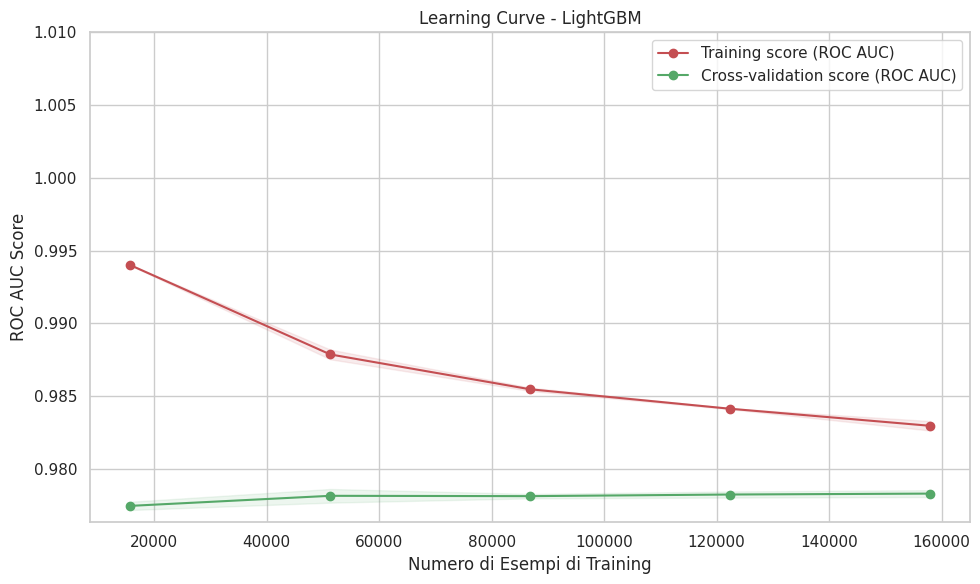


Punteggio medio finale di Cross-Validation (con 157932 esempi) per LightGBM: 0.9783


In [28]:
#Learning Curve
train_sizes_proportions_lgbm = np.linspace(0.1, 1.0, 5)

train_sizes_abs_lgbm, train_scores_lgbm, validation_scores_lgbm = learning_curve(
    estimator=pipeline_lgbm,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions_lgbm,
    cv=3, #per tempo inferiore di esecuzione
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi
train_scores_mean_lgbm = np.mean(train_scores_lgbm, axis=1)
train_scores_std_lgbm = np.std(train_scores_lgbm, axis=1)
validation_scores_mean_lgbm = np.mean(validation_scores_lgbm, axis=1)
validation_scores_std_lgbm = np.std(validation_scores_lgbm, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs_lgbm, train_scores_mean_lgbm - train_scores_std_lgbm,
                  train_scores_mean_lgbm + train_scores_std_lgbm, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs_lgbm, validation_scores_mean_lgbm - validation_scores_std_lgbm,
                  validation_scores_mean_lgbm + validation_scores_std_lgbm, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs_lgbm, train_scores_mean_lgbm, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs_lgbm, validation_scores_mean_lgbm, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - LightGBM")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_lgbm[-1]} esempi) per LightGBM: {validation_scores_mean_lgbm[-1]:.4f}")

###5.8 Modello 7: XGBoost

In [29]:
# Modello 8: XGBoost

print("Modello 8: XGBoost")
#gestione dello sbilanciamento con scale_pos_weight
#calcolo scale_pos_weight: num_negative_samples / num_positive_samples

if isinstance(y_train, pd.Series):
    counts = y_train.value_counts()
    scale_pos_weight_xgb = counts.get(0, 0) / counts.get(1, 1) if counts.get(1,1) > 0 else 1
else: #y_train array numpy
    unique_elements, counts_elements = np.unique(y_train, return_counts=True)
    if len(counts_elements) == 2:
          scale_pos_weight_xgb = counts_elements[0] / counts_elements[1] if counts_elements[1] > 0 else 1
    else: #classe singola formato inatteso
        scale_pos_weight_xgb = 1
        print("Impossibile calcolare scale_pos_weight per XGBoost, impostato a 1.")

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                  reg_lambda=1.5, reg_alpha=0.1, #regolarizzazione L2 e L1 (da sezione finetuning)
                                  use_label_encoder=False, eval_metric='logloss',
                                  scale_pos_weight=scale_pos_weight_xgb))
])
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
model_results['XGBoost'] = {'pred': y_pred_xgb, 'prob': y_prob_xgb, 'pipeline': pipeline_xgb}
print(">>Valutazione XGBoost:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}\n")

Modello 8: XGBoost
>>Valutazione XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     92612
           1       0.65      0.99      0.78      8917

    accuracy                           0.95    101529
   macro avg       0.82      0.97      0.88    101529
weighted avg       0.97      0.95      0.96    101529

ROC AUC: 0.9781



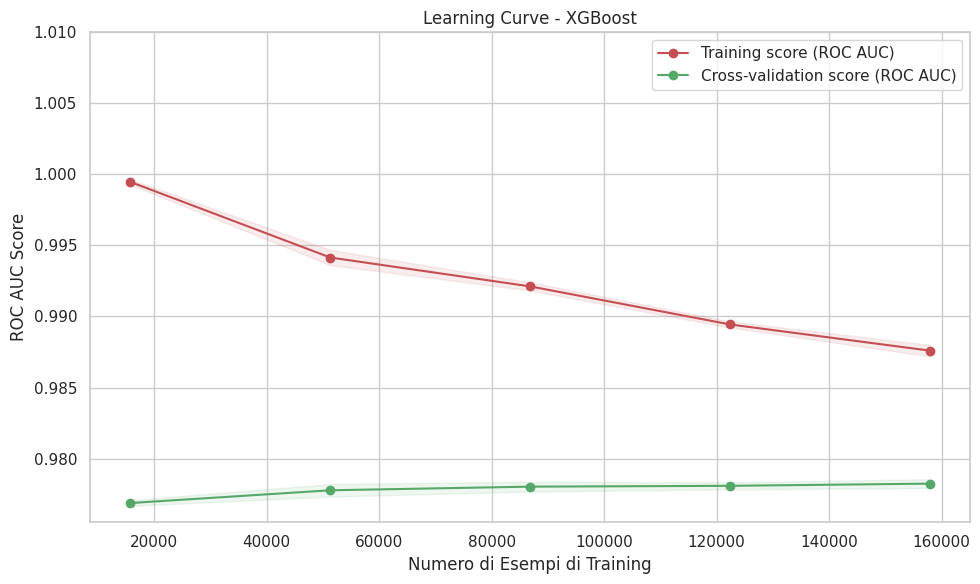


Punteggio medio finale di Cross-Validation (con 157932 esempi) per XGBoost: 0.9782


In [30]:
#Learning Curve
train_sizes_proportions_xgb = np.linspace(0.1, 1.0, 5)

train_sizes_abs_xgb, train_scores_xgb, validation_scores_xgb = learning_curve(
    estimator=pipeline_xgb,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes_proportions_xgb,
    cv=3, #esecuzione più veloce
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

#calcolo media e deviazione standard dei punteggi
train_scores_mean_xgb = np.mean(train_scores_xgb, axis=1)
train_scores_std_xgb = np.std(train_scores_xgb, axis=1)
validation_scores_mean_xgb = np.mean(validation_scores_xgb, axis=1)
validation_scores_std_xgb = np.std(validation_scores_xgb, axis=1)

plt.figure(figsize=(10, 6))

#area deviazione standard
plt.fill_between(train_sizes_abs_xgb, train_scores_mean_xgb - train_scores_std_xgb,
                  train_scores_mean_xgb + train_scores_std_xgb, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs_xgb, validation_scores_mean_xgb - validation_scores_std_xgb,
                  validation_scores_mean_xgb + validation_scores_std_xgb, alpha=0.1, color="g")

#curve delle medie
plt.plot(train_sizes_abs_xgb, train_scores_mean_xgb, 'o-', color="r",
          label="Training score (ROC AUC)")
plt.plot(train_sizes_abs_xgb, validation_scores_mean_xgb, 'o-', color="g",
          label="Cross-validation score (ROC AUC)")

plt.title("Learning Curve - XGBoost")
plt.xlabel("Numero di Esempi di Training")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(None, 1.01)
plt.tight_layout()
plt.show()

#punteggio
print(f"\nPunteggio medio finale di Cross-Validation (con {train_sizes_abs_xgb[-1]} esempi) per XGBoost: {validation_scores_mean_xgb[-1]:.4f}")

Considerato che non si ha un obiettivo specifico, come ad esempio minimizzare i falsi positivi o falsi negativi, la scelta del miglior modello seguirà solo la metrica più generale ROC AUC.<br>
I primi tre migliori modelli sono:
1. LightGBM
2. XGBoost
3. Multilayer perceptron

<br>
In tutti i casi l'overfitting è pressochè assente però è possibile trarre alcune considerazioni dalle learning curves:
- Nel caso del modello Naive Bayes si osserva un andamento altalenante e in alcuni casi anche aumento della varianza. Il modello è stabile e si ha convergenza costante però il modello sembra essere sensibile alla composizione del campione.
- Nel caso del Multilayer Perceptron l'assenza di regolarizzazione causa overfitting, invece implementandola si ha una ottima convergenza.
- Nel caso dei modelli LightGBM e XGBoost sembra non ci sia convergenza ma è una questione di scala del grafico, infatti la distanza tra le due curve per il LightGBM è circa 0,005 sul ROC AUC score, invece la distanza tra le curve per il XGBoost è circa 0,01. Le distanze sono sufficientemente piccole da non poter parlare effettivamente di overfitting. In ogni caso la tendenza è alla convergenza.

#6 Valutazione e confronto tra modelli

In questa sezione vengono aggregate le metriche di valutazione dei diversi modelli in una sola tabella (modelli ordinati da quello con ROC AUC maggiore a quello con ROC AUC minore), sono mostrate le ROC curve a confronto (il box mostra l'ordine dal miglior modello al peggiore) e le matrici di confusione.

In [31]:
results_list = []
roc_plot_data = {}

for name, result in model_results.items():
    if result.get('pred') is None or result.get('prob') is None:
        continue

    pred = result['pred']
    prob = result['prob']
    pipeline = result['pipeline']

    # Calcola metriche
    results_list.append({
        'Modello': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (Class 1)': precision_score(y_test, pred, pos_label=1, zero_division=0),
        'Recall (Class 1)': recall_score(y_test, pred, pos_label=1, zero_division=0),
        'F1-Score (Class 1)': f1_score(y_test, pred, pos_label=1, zero_division=0),
        'ROC AUC': roc_auc_score(y_test, prob)
    })
    # Salva dati per plot ROC
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_plot_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_score(y_test, prob)}

In [32]:
#performance modelli (ordinamento in base a roc auc)
results_df = pd.DataFrame(results_list).round(4).sort_values(by='ROC AUC', ascending=False)
print(">>>>>Riepilogo performance modelli:")
print(results_df)

>>>>>Riepilogo performance modelli:
                        Modello  Accuracy  Precision (Class 1)  \
5                      LightGBM    0.9507               0.6421   
6                       XGBoost    0.9522               0.6497   
4          MLP Classifier + RUS    0.9470               0.6252   
1                 Decision Tree    0.9479               0.6289   
2                 Random Forest    0.9489               0.6337   
0           Logistic Regression    0.8260               0.3219   
3  Naive Bayes (Gaussian + RUS)    0.3250               0.1125   

   Recall (Class 1)  F1-Score (Class 1)  ROC AUC  
5            0.9910              0.7793   0.9782  
6            0.9896              0.7844   0.9781  
4            0.9899              0.7664   0.9779  
1            0.9914              0.7696   0.9760  
2            0.9906              0.7729   0.9753  
0            0.8870              0.4724   0.9190  
3            0.9710              0.2017   0.8034  


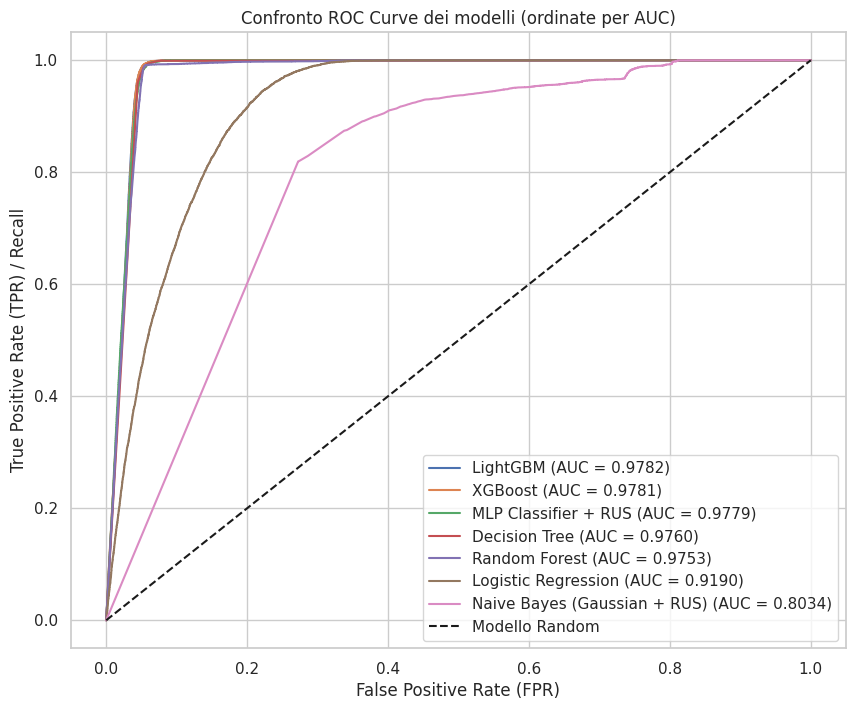

In [33]:
plt.figure(figsize=(10, 8))

#ordinamento modelli in base all'AUC (ordine decrescente)
sorted_models = sorted(roc_plot_data.items(), key=lambda item: item[1]['auc'], reverse=True)

#plot roc curve
for name, data in sorted_models:
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Modello Random') # Linea di base casuale
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Confronto ROC Curve dei modelli (ordinate per AUC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


>>>>>Matrici di confusione dei modelli:


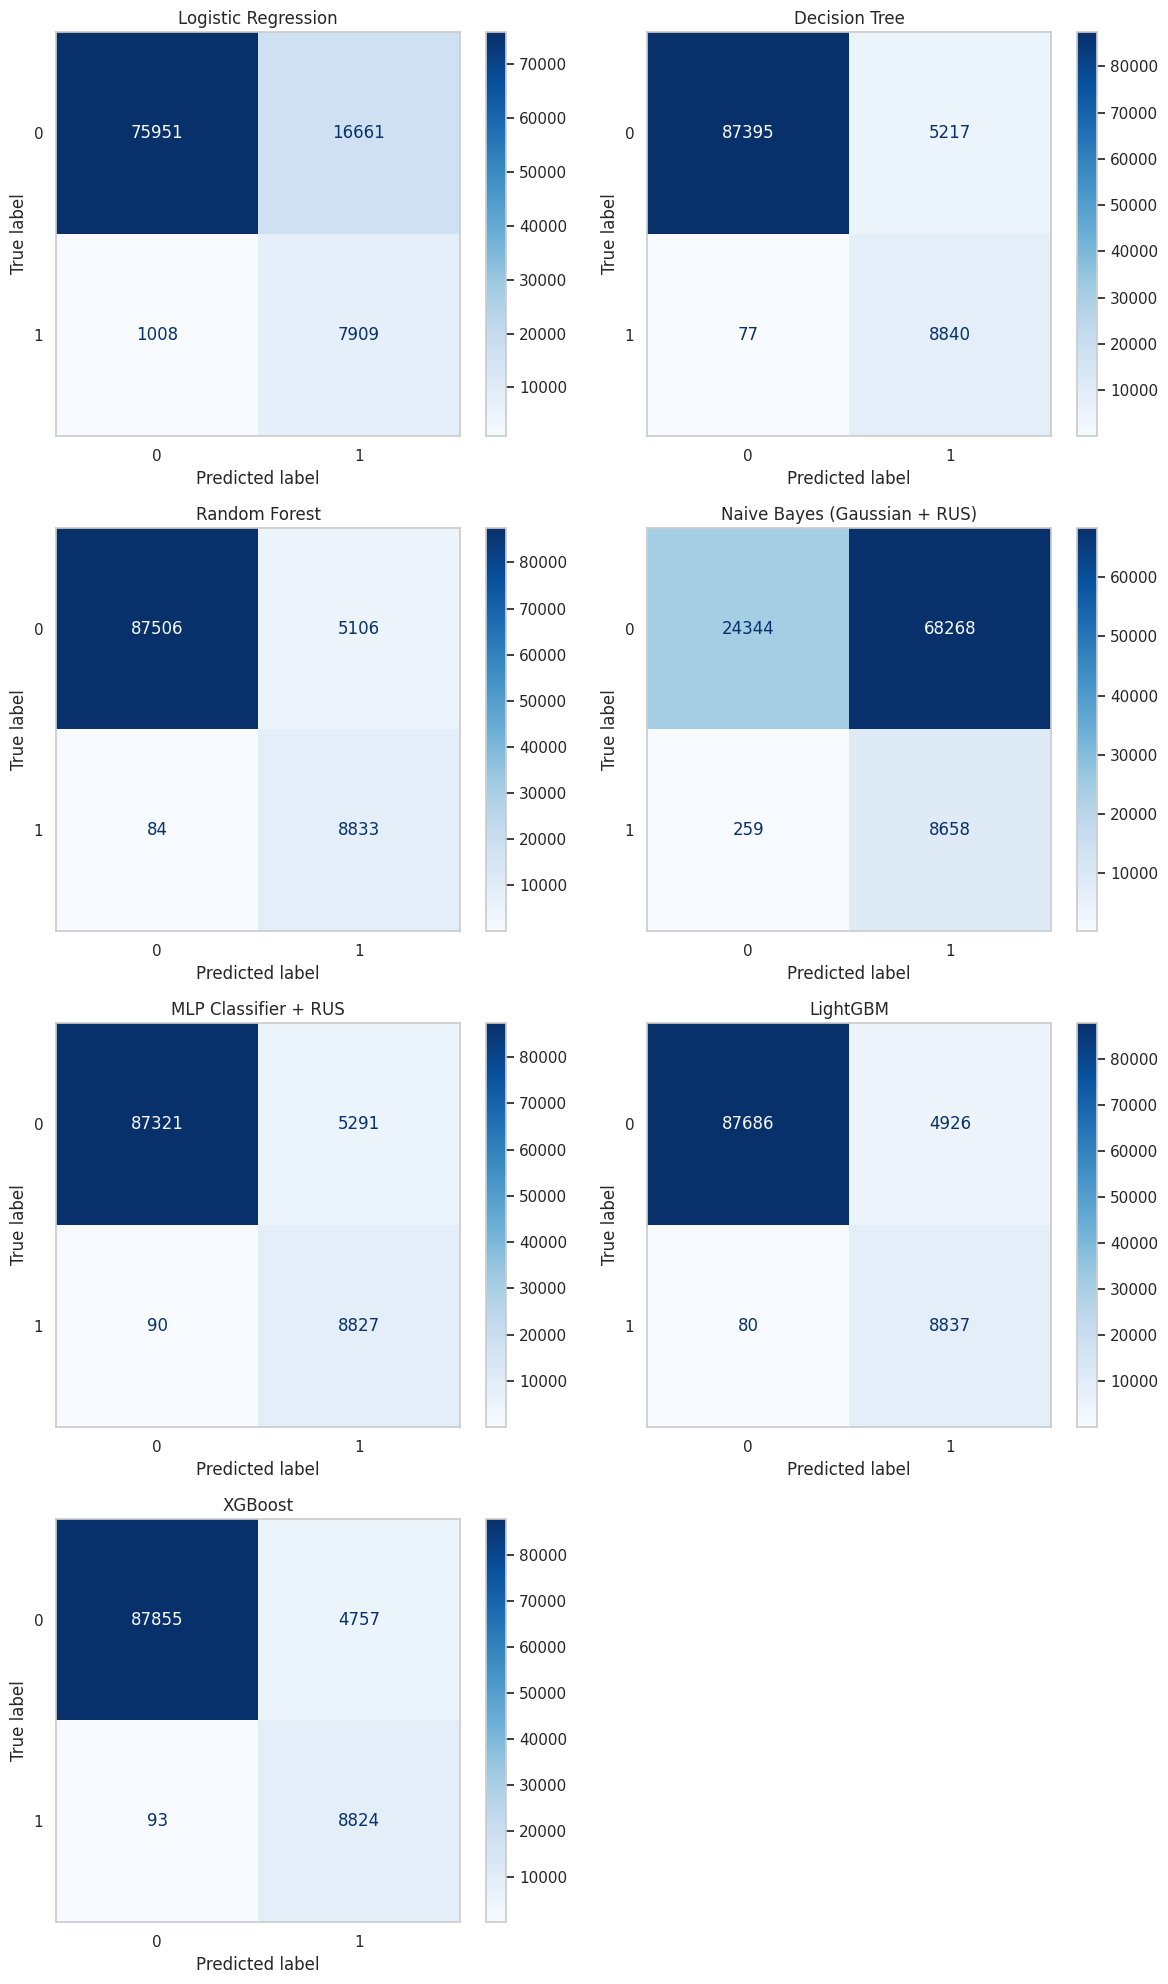

In [34]:
#matrici di confusione
print(">>>>>Matrici di confusione dei modelli:")
n_models = len(model_results)
if n_models > 0:
    #calcolo delle righe/colonne per subplot
    n_cols = 2
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    model_names = list(model_results.keys())
    for i, name in enumerate(model_names):
        result = model_results[name]
        if result.get('pred') is None: continue
        cm = confusion_matrix(y_test, result['pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d')
        axes[i].set_title(f"{name}")
        axes[i].grid(False)

    #nasconde assi vuoti se il numero di modelli non è multiplo di n_cols
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()





A conferma della coerenza dei risultati, le matrici di confusione migliori sono quelle per il LightGBM e XGBoost. Le ROC curves sono esattamente nell'ordine e nell'andamento atteso.

#7 Interpretabilità

Nella presente sezione viene condotta un'analisi di interpretabilità dei diversi modelli e viene commentata l'analisi relativa al modello con performance più elevate (LightGBM).<br>
<br>
Di seguito una breve guida per i metodi interpretativi scelti:
- **Logistic regression**: coefficienti (segno ed intensità) per ogni feature sia in termini numerici che grafici.
- **Decision tree**: struttura dell'albero e importance (intensità) per ogni feature sia in termini numerici che grafici.<br>
Importance=somma totale della riduzione dell'impurità di Gini che quella feature apporta su tutti gli split in cui è stata utilizzata nell'albero.
- **Random forest**: importance (intensità) per ogni feature sia in termini numerici che grafici.<br>
La importance è calcolata in modo simile ad un singolo albero decisionale, ma viene "mediata" su tutti gli alberi che compongono la foresta.
- **Naive bayes**: medie e varianze di ogni feature per ogni classe di target.<br>
theta= valore medio della feature per una specifica classe target; var=quanto i valori della feature si disperdono attorno alla media per quella specifica classe target.
- **Multilayer perceptron**: permutation importance (segno ed intensità) e valori shap (distribuzione grafica ed intensità). Si evidenzia che, in generale, questo modello è di difficile interpretazione.
- **LightGBM**: split importance (intensità) per ogni feature sia in termini numerici che grafici.
- **XGBoost**: gain importance (intensità) per ogni feature sia in termini numerici che grafici





**Approfondimento interpretazione multilayer perceptron**<br>
La **permutation importance** è una tecnica per calcolare l'importanza di una feature. Tale tecnica segue alcune fasi:
1. Si parte dal modello già addestrato;
2. Si calcola una metrica di performance del modello su un set di dati (solitamente di test);
3. per ogni feature, i valori di quella specifica feature vengono mescolati casualmente (permutati) nel set di dati così da generare una "corruzione" della relazione tra quella feature e la variabile target;
4. Si calcolano nuove previsioni con il modello usando il dataset modificato (con una colonna "scombinata");
5. Si ricalcola la metrica di performance;
6. Viene calcolata l'importanza della feature rappresentata dalla diminuzione della performance del modello dopo la permutazione di quella feature, dunque se la performance cala molto allora la feature è considerata molto importante, se invece la performance cala poco o resta stabile allora la feature è considerata poco importante.<br>

I **valori SHAP** (SHapley Additive exPlanations) rappresentano un altro approccio, basato sulla teoria dei giochi, per spiegare le previsioni di qualsiasi modello (utile nel caso di MLP) ed assegnare a ciascuna feature un valore di importanza per ogni singola previsione.<br>
L'idea è la seguente: se un gruppo di giocatori coopera per ottenere un certo guadagno (la previsione del modello), come si dovrebbe distribuire equamente il merito di quel guadagno tra i giocatori (le feature)?
- Un valore SHAP dice quanto ogni giocatore (feature) ha contribuito marginalmente al guadagno finale (la previsione), considerando tutti i possibili modi in cui i giocatori avrebbero potuto unirsi al gioco (cioè, tutti i possibili sottoinsiemi e ordinamenti delle feature).
- Per una specifica previsione fatta dal modello (ad esempio, la probabilità che il cliente X sia insolvente), un valore SHAP dice quanto la specifica caratteristica (feature) di quello specifico cliente ha contribuito a spostare la previsione rispetto a una previsione media di base (quella del modello stimato inizialmente).
- Un valore SHAP positivo indica che il valore di quella feature per quel cliente ha spinto la previsione del modello verso l'alto (ad esempio, aumentando la probabilità di insolvenza, o verso la classe "1"). Invece un valore SHAP negativo indica che il valore di quella feature per quel cliente ha spinto la previsione del modello verso il basso (ad esempio, diminuendo la probabilità di insolvenza, o verso la classe "0").

**Approfondimento interpretazione LightGBM**<br>
1. LightGBM costruisce un insieme (ensemble) di alberi decisionali
2. Ogni albero decisionale viene costruito dividendo i dati in nodi basandosi sui valori delle feature (split nei nodi)
3. Ogni divisione (split) è fatta scegliendo la feature e il valore di soglia che meglio separano i dati rispetto all'obiettivo di classificazione.
4. L'importanza di tipo split (split importance, o feature usage) conta quante volte una feature è stata utilizzata per effettuare uno split in un nodo, sommando su tutti gli alberi dell'ensemble LightGBM. In tal modo è possibile individuare le variabili più frequentemente utili al modello per prendere le decisioni di classificazione, sulla base del numero di volte che sono state scelte per creare delle divisioni negli alberi.

**Approfondimento interpretazione XGBoost**<br>
1. XGBoost costruisce una serie di alberi decisionali in modo sequenziale, dove ogni nuovo albero cerca di correggere gli errori commessi dagli alberi precedenti.
2. Quando viene costruito un albero, ogni split (divisione di un nodo) viene scelto per massimizzare il miglioramento di una metrica obiettivo (legata alla funzione di perdita del modello). Tale miglioramento è chiamato "gain" (guadagno). In sostanza, il gain misura quanto uno split, utilizzando una particolare feature, contribuisce a ridurre l'errore del modello o a migliorare la sua capacità predittiva.
3. L'importanza di tipo gain per una feature è il contributo medio di quella feature al miglioramento del modello (riduzione della perdita) ogni volta che è stata utilizzata per uno split, calcolato su tutti gli alberi dell'ensemble XGBoost. Questi valori vengono poi solitamente normalizzati in modo che la loro somma sia 1 così da rappresentare la frazione del contributo al totale.

***NOTA PER IL LETTORE: Per non appesantire la lettura, nella seguente cella si può scegliere il modello di cui visualizzare l'interpretazione***

Seleziona il modello di cui visualizzare l'interpretazione:
Digitare 0 per il modello: Logistic Regression
Digitare 1 per il modello: Decision Tree
Digitare 2 per il modello: Random Forest
Digitare 3 per il modello: Naive Bayes (Gaussian + RUS)
Digitare 4 per il modello: MLP Classifier + RUS
Digitare 5 per il modello: LightGBM
Digitare 6 per il modello: XGBoost
Inserisci un numero da 0 a 6 (o 'q' per uscire): 5
Hai selezionato: LightGBM
Analisi interpretabilità per: LightGBM
Nomi delle feature processate ottenuti (64). Esempio: ['num__CNT_CHILDREN', 'num__AMT_INCOME_TOTAL', 'num__CNT_FAM_MEMBERS', 'num__AGE_YEARS', 'num__YEARS_EMPLOYED']
Nomi feature originali ottenuti da X_train (17). Esempio: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']
Classificatore estratto: LGBMClassifier

Importanza delle Feature per LGBMClassifier:
                                              Feature  Importance
1                               num__AMT_INCOME_TOTAL    

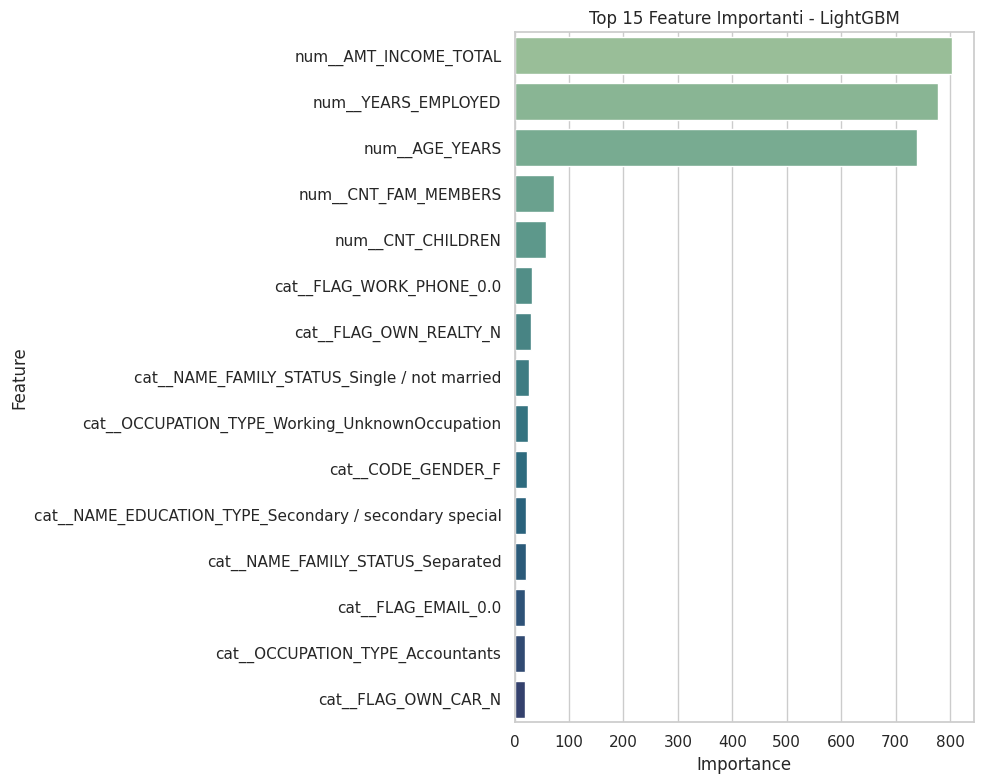

In [35]:
print("Seleziona il modello di cui visualizzare l'interpretazione:")

available_models = list(model_results.keys())
for i, model_name_option in enumerate(available_models):
    print(f"Digitare {i} per il modello: {model_name_option}")

model_name_to_interpret = None
choice_str = ''
while True:
    try:
        choice_str = input(f"Inserisci un numero da 0 a {len(available_models) - 1} (o 'q' per uscire): ")
        if choice_str.lower() == 'q':
            print("Selezione annullata dall'utente.")
            break
        model_index = int(choice_str)
        if 0 <= model_index < len(available_models):
            model_name_to_interpret = available_models[model_index]
            print(f"Hai selezionato: {model_name_to_interpret}")
            break
        else:
            print(f"Scelta non valida. Inserisci un numero compreso tra 0 e {len(available_models) - 1}.")
    except ValueError:
        print("Input non valido. Inserisci un numero intero.")
    except Exception as e:
        print(f"Si è verificato un errore imprevisto durante la selezione: {e}")
        break


#Modello selezionato dall'utente
if model_name_to_interpret and model_name_to_interpret in model_results:
    print(f"======================================================================")
    print(f"Analisi interpretabilità per: {model_name_to_interpret}")
    print(f"======================================================================")

    pipeline_to_interpret = model_results[model_name_to_interpret]['pipeline']

    feature_names_processed = None #nomi feature dopo il preprocessor
    preprocessor_step = None
    #ricerca preprocessor nella pipeline
    if 'preprocessor' in pipeline_to_interpret.named_steps:
        preprocessor_step = pipeline_to_interpret.named_steps['preprocessor']
    elif pipeline_to_interpret.steps and hasattr(pipeline_to_interpret.steps[0][1], 'transform'):
          #euristica: considero il primo step se è un trasformatore
        candidate_preprocessor = pipeline_to_interpret.steps[0][1]
        if hasattr(candidate_preprocessor, 'get_feature_names_out') or hasattr(candidate_preprocessor, 'transformers_'):
            preprocessor_step = candidate_preprocessor
            print("Inferito preprocessor dal primo step della pipeline.")

    if preprocessor_step is not None:
        try:
            if hasattr(preprocessor_step, 'get_feature_names_out'):
                #per ColumnTransformer e simili
                feature_names_processed = list(preprocessor_step.get_feature_names_out())
                print(f"Nomi delle feature processate ottenuti ({len(feature_names_processed)}). Esempio: {feature_names_processed[:min(5, len(feature_names_processed))]}")
            else:
                print("Il preprocessor identificato non ha 'get_feature_names_out'. Potrebbe essere difficile ottenere i nomi delle feature processate.")
        except Exception as e:
            print(f"Impossibile ottenere i nomi delle feature dal preprocessor: {e}")
    else:
        print("Nessuno step 'preprocessor' trovato esplicitamente o inferito come primo step della pipeline.")


    #nomi feature originali
    feature_names_original = None
    if 'X_train' in globals() and isinstance(X_train, pd.DataFrame):
        feature_names_original = X_train.columns.tolist()
        print(f"Nomi feature originali ottenuti da X_train ({len(feature_names_original)}). Esempio: {feature_names_original[:min(5, len(feature_names_original))]}")
    elif 'X_train' in globals(): # Se X_train esiste ma non è DataFrame
        try:
            num_cols = X_train.shape[1]
            feature_names_original = [f"feature_{i}" for i in range(num_cols)]
            print(f"X_train non è un DataFrame. Usando nomi generici per le feature originali ({len(feature_names_original)}): {feature_names_original[:min(5, len(feature_names_original))]}")
        except Exception as e:
            print(f"X_train non è un DataFrame e la sua forma non è accessibile per generare nomi feature originali generici: {e}")
    else:
        print("X_train non trovato nello scope globale. I nomi delle feature originali non possono essere determinati.")


    #estrazione del classificatore dalla pipeline
    classifier = None
    pipeline_steps = pipeline_to_interpret.steps
    if 'classifier' in pipeline_to_interpret.named_steps:
        classifier = pipeline_to_interpret.named_steps['classifier']
    elif 'model' in pipeline_to_interpret.named_steps: #nome alternativo
        classifier = pipeline_to_interpret.named_steps['model']
    elif pipeline_steps: #prende l'ultimo step se i nomi standard non ci sono
        classifier = pipeline_steps[-1][1]
    else:
          print("La pipeline sembra vuota o non strutturata come previsto.")

    if classifier is None:
        print("Classificatore non trovato nella pipeline.")
    else:
        print(f"Classificatore estratto: {type(classifier).__name__}")

        current_feature_names_for_model = feature_names_processed if feature_names_processed is not None else feature_names_original
        current_random_state = globals().get('RANDOM_STATE')


        #LOGISTIC REGRESSION
        if isinstance(classifier, LogisticRegression):
            if current_feature_names_for_model is not None and hasattr(classifier, 'coef_') and classifier.coef_[0].size > 0 :
                if len(current_feature_names_for_model) == classifier.coef_[0].shape[0]:
                    print("\nCoefficienti del Modello Logistico:")
                    coefficients = pd.DataFrame({
                        'Feature': current_feature_names_for_model,
                        'Coefficient': classifier.coef_[0]
                    }).sort_values(by='Coefficient', key=abs, ascending=False)
                    print(coefficients.head(20))
                    plt.figure(figsize=(10, max(6, min(10, len(coefficients)//2))))
                    sns.barplot(x='Coefficient', y='Feature', data=coefficients.head(20), palette='coolwarm')
                    plt.title(f'Top 20 Coefficienti - {model_name_to_interpret}')
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"Mismatch lunghezza nomi feature ({len(current_feature_names_for_model)}) e coeff. ({classifier.coef_[0].shape[0]})")
            else:
                print("Nomi feature o coefficienti (vuoti o non disponibili) per Logistic Regression.")

        #DECISION TREE
        elif isinstance(classifier, DecisionTreeClassifier):
            print("\nVisualizzazione Albero Decisionale (limitata profondità):")
            if current_feature_names_for_model:
                fig_width = min(40, 5 + len(current_feature_names_for_model))
                fig_height = min(25, 3 + len(current_feature_names_for_model)//3)
                font_size = max(6, 12 - len(current_feature_names_for_model)//20) #dimensione font dinamica
                plt.figure(figsize=(fig_width, fig_height))
                try:
                    plot_tree(classifier,
                              feature_names=current_feature_names_for_model,
                              class_names=['0 (Rischioso)', '1 (Affidabile)'], #adatta se le tue classi sono diverse
                              filled=True, proportion=True, max_depth=3, fontsize=font_size, rounded=True)
                    plt.title(f"Albero Decisionale - {model_name_to_interpret} (Profondità max 3)")
                    plt.show()
                except Exception as e:
                    print(f"Errore visualizzazione albero: {e}. Potrebbe essere dovuto a un mismatch con i nomi delle feature o troppe feature.")
            else:
                print("Nomi delle feature (processate o originali) non disponibili per visualizzare l'albero decisionale.")


            if current_feature_names_for_model is not None and hasattr(classifier, 'feature_importances_'):
                if len(current_feature_names_for_model) == len(classifier.feature_importances_):
                    print("\nImportanza delle Feature (Gini) per Decision Tree:")
                    importances_dt = pd.DataFrame({
                        'Feature': current_feature_names_for_model,
                        'Importance': classifier.feature_importances_
                    }).sort_values(by='Importance', ascending=False)
                    print(importances_dt.head(20))
                    plt.figure(figsize=(10, max(8, len(importances_dt.head(15)) // 2)))
                    sns.barplot(x='Importance', y='Feature', data=importances_dt.head(15), palette='viridis')
                    plt.title(f'Top 15 Feature Importanti (Gini) - {model_name_to_interpret}')
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"Mismatch lunghezza nomi feature ({len(current_feature_names_for_model)}) e importances ({len(classifier.feature_importances_)})")
            else:
                print("Nomi feature o feature_importances_ non disponibili per Decision Tree.")

        #ENSEMBLE TREES (ovvero RF, LGBM, XGB)
        elif isinstance(classifier, (RandomForestClassifier, LGBMClassifier, XGBClassifier)):
            model_type_name = classifier.__class__.__name__
            if current_feature_names_for_model is not None and hasattr(classifier, 'feature_importances_'):
                if len(current_feature_names_for_model) == len(classifier.feature_importances_):
                    print(f"\nImportanza delle Feature per {model_type_name}:")
                    importances = pd.DataFrame({
                        'Feature': current_feature_names_for_model,
                        'Importance': classifier.feature_importances_
                    }).sort_values(by='Importance', ascending=False)
                    print(importances.head(20))
                    plt.figure(figsize=(10, max(8, len(importances.head(15)) // 2)))
                    sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='crest')
                    plt.title(f'Top 15 Feature Importanti - {model_name_to_interpret}')
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"Mismatch lunghezza nomi feature ({len(current_feature_names_for_model)}) e importances ({len(classifier.feature_importances_)}) per {model_type_name}")
            else:
                print(f"Nomi feature o feature_importances_ non disponibili per {model_type_name}.")

        #GAUSSIAN NAIVE BAYES
        elif isinstance(classifier, GaussianNB):
            sigma_attr_name = 'var_' if hasattr(classifier, 'var_') else 'sigma_' #gestisce deprecazione
            print("\nInterpretazione per Naive Bayes (GaussianNB):")
            if current_feature_names_for_model is not None and hasattr(classifier, 'theta_') and hasattr(classifier, sigma_attr_name):
                variances_ = getattr(classifier, sigma_attr_name)
                if len(current_feature_names_for_model) == classifier.theta_.shape[1] and \
                    len(current_feature_names_for_model) == variances_.shape[1]:
                    print("\nMedie delle feature per classe (theta_):")
                    df_theta = pd.DataFrame(classifier.theta_, columns=current_feature_names_for_model, index=classifier.classes_ if hasattr(classifier, 'classes_') else [f"Classe {i}" for i in range(classifier.theta_.shape[0])])
                    print(df_theta.head().T) #trasposto per leggibilità

                    print(f"\nVarianze (o {sigma_attr_name}) delle feature per classe:")
                    df_var = pd.DataFrame(variances_, columns=current_feature_names_for_model, index=classifier.classes_ if hasattr(classifier, 'classes_') else [f"Classe {i}" for i in range(variances_.shape[0])])
                    print(df_var.head().T) #trasposto
                else:
                    print(f"Mismatch lunghezza nomi feature ({len(current_feature_names_for_model)}) e parametri Naive Bayes (theta: {classifier.theta_.shape[1]}, {sigma_attr_name}: {variances_.shape[1]}).")
            else:
                print(f"Nomi feature, theta_ o {sigma_attr_name} non disponibili per Naive Bayes.")

        #MLP CLASSIFIER
        elif isinstance(classifier, MLPClassifier):
            print("\nInterpretazione per MLP Classifier (tipicamente via Permutation Importance o SHAP sull'intera pipeline):")
            if 'X_test' not in globals() or 'y_test' not in globals() or 'X_train' not in globals():
                print("X_train, X_test, y_test non trovati nello scope globale. Impossibile calcolare SHAP o Permutation Importance per MLP.")
            elif feature_names_original is None: #SHAP/Permutation per MLP usano feature_names_original
                print("Nomi delle feature originali non disponibili (es. X_train non è DataFrame o manca). Permutation/SHAP sull'intera pipeline richiede questi nomi.")
            else:
                X_test_mlp_interpret = X_test
                y_test_mlp_interpret = y_test
                X_train_mlp_background = X_train

                #Permutation Importance (sull'intera pipeline)
                print("\nCalcolo Permutation Importance per MLP (sull'intera pipeline)...")
                try:
                    perm_result = permutation_importance(
                        pipeline_to_interpret, X_test_mlp_interpret, y_test_mlp_interpret,
                        n_repeats=10, random_state=current_random_state, n_jobs=-1, scoring='roc_auc'
                    )
                    perm_sorted_idx = perm_result.importances_mean.argsort()[::-1]

                    perm_df = pd.DataFrame({
                        'Feature': [feature_names_original[i] for i in perm_sorted_idx][:20],
                        'Importance': perm_result.importances_mean[perm_sorted_idx][:20]
                    })
                    print("Top 20 Feature per Permutation Importance (MLP sulla pipeline):")
                    print(perm_df)

                    plt.figure(figsize=(10, 8))
                    sns.barplot(x='Importance', y='Feature', data=perm_df.head(15), palette='cubehelix')
                    plt.title(f'Permutation Importance (Top 15) - {model_name_to_interpret}')
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f"Errore durante il calcolo della Permutation Importance per MLP: {e}")

                #SHAP (sull'intera pipeline)
                print("\nCalcolo SHAP values per MLP (sull'intera pipeline, potrebbe richiedere tempo)...")
                try:
                    def mlp_pipeline_predict_proba_for_shap(data_input_shap):
                        #controllo che l'input per la pipeline sia un dataframe se X_train originale era un dataframe...
                        if isinstance(X_train_mlp_background, pd.DataFrame):
                            data_input_df = pd.DataFrame(data_input_shap, columns=feature_names_original)
                            return pipeline_to_interpret.predict_proba(data_input_df)
                        else: #...altrimenti passa come array NumPy
                            return pipeline_to_interpret.predict_proba(data_input_shap)

                    n_background_samples = min(100, X_train_mlp_background.shape[0])
                    n_explain_samples = min(100, X_test_mlp_interpret.shape[0])

                    background_data_shap = shap.sample(X_train_mlp_background, n_background_samples, random_state=current_random_state)
                    #per KernelExplainer, test_data_shap deve essere nel formato originale atteso dalla pipeline
                    #se X_test_mlp_interpret è un dataframe, shap.sample restituirà un dataframe
                    #se è un array numpy, restituirà un array numpy
                    test_data_shap_samples = shap.sample(X_test_mlp_interpret, n_explain_samples, random_state=current_random_state)

                    explainer_mlp_pipeline = shap.KernelExplainer(model=mlp_pipeline_predict_proba_for_shap, data=background_data_shap)

                    print(f"Calcolo SHAP values effettivi su {n_explain_samples} campioni di test...")
                    shap_values_mlp_pipeline = explainer_mlp_pipeline.shap_values(test_data_shap_samples, nsamples='auto')

                    print("Visualizzazione SHAP Summary Plot...")
                    shap_output_index = 1 #per la classe positiva in classificazione binaria

                    shap_values_for_plot = None
                    #gestione del formato di shap_values_mlp_pipeline
                    if isinstance(shap_values_mlp_pipeline, list):
                        if len(shap_values_mlp_pipeline) > shap_output_index:
                            shap_values_for_plot = shap_values_mlp_pipeline[shap_output_index]
                        else:
                            print(f"Errore: shap_output_index ({shap_output_index}) non è valido per la lista shap_values_mlp_pipeline.")
                    elif isinstance(shap_values_mlp_pipeline, np.ndarray) and shap_values_mlp_pipeline.ndim == 3:
                        #array 3D (campioni, feature, classi)
                        if shap_values_mlp_pipeline.shape[2] > shap_output_index:
                            shap_values_for_plot = shap_values_mlp_pipeline[:, :, shap_output_index]
                        else:
                            print(f"Errore: shap_output_index ({shap_output_index}) non è valido per l'array 3D shap_values_mlp_pipeline.")
                    elif isinstance(shap_values_mlp_pipeline, np.ndarray) and shap_values_mlp_pipeline.ndim == 2:
                        #un array 2D (campioni, features)
                        shap_values_for_plot = shap_values_mlp_pipeline
                    else:
                        print(f"Formato SHAP values non riconosciuto restituito da KernelExplainer: {type(shap_values_mlp_pipeline)}. Atteso list o numpy.ndarray 3D/2D.")

                    if shap_values_for_plot is not None:
                        #per shap.summary_plot, se test_data_shap_samples è un array numpy, feature_names deve essere fornito.
                        #se è un dataframe, i nomi delle colonne vengono usati automaticamente
                        if isinstance(test_data_shap_samples, pd.DataFrame):
                            shap.summary_plot(shap_values_for_plot, test_data_shap_samples, show=False)
                        else: #array numpy
                            shap.summary_plot(shap_values_for_plot, test_data_shap_samples, feature_names=feature_names_original, show=False)

                        plt.title(f"SHAP Summary Plot (Classe {shap_output_index}) - {model_name_to_interpret}")
                        plt.tight_layout()
                        plt.show()
                    else:
                        print("Impossibile generare SHAP summary plot a causa di problemi con i dati SHAP o l'indice.")

                except Exception as e:
                    print(f"Errore durante il calcolo o la visualizzazione dei SHAP values per MLP: {e}")

elif choice_str.lower() != 'q': #se l'utente non ha scelto 'q' ma model_name_to_interpret non è valido o non trovato
    if model_name_to_interpret: #se un nome è stato selezionato ma non è in model_results
        print(f"Modello '{model_name_to_interpret}' selezionato ma non trovato in model_results.")

YEARS_EMPLOYED, AMT_INCOME_TOTAL, AGE_YEARS

Per il modello LightGBM (il miglior modello tra quelli addestrati), le feature YEARS_EMPLOYED, AMT_INCOME_TOTAL e AGE_YEARS sono le più utili per distinguere tra le classi della variabile target (ovvero il modello le usa molto frequentemente per costruire gli alberi decisionali). D'altra parte, le feature con un conteggio di importance più basso sono usate meno spesso, indicando così un ruolo meno centrale nel processo decisionale del modello. <br>
È bene osservare che le variabili risultate rilevanti sono anche "logiche" per spiegare la variabile target. Infatti, il numero di giorni di assunzione, il reddito annuale e l'età dell'individuo sono variabili logicamente utili a spiegare l'affidabilità creditizia.

#8 Approfondimento: Finetuning

In questa ultima sezione viene proposto un approfondimento in cui vengono riaddestrati tutti i modelli, vengono mostrati gli iperparametri ottimali e le performace del modello (sia quelle del modello che conduce alla stima degli iperparametri, sia del modello riaddestrato con gli iperparametri ottimali). Per una esecuzione più o meno veloce viene implementato la randomized search cv.

In [36]:
#IL TEMPO NECESSARIO PER L'ESECUZIONE CON 3 ITERAZIONI E DI CIRCA 20 MINUTI CON CPU E 10 CON GPU
#per salvare i risultati dei modelli ottimizzati con Random Search
tuned_model_results_rs = {}

#numero di iterazioni per RandomizedSearchCV (quante combinazioni di parametri provare)
N_ITER_SEARCH = 3

#Modello 1: Logistic Regression
print(">>>>> Modello 1: Logistic Regression - Fine-tuning (RandomizedSearchCV)")
pipeline_lr_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, solver='liblinear', max_iter=2000))
])

#distribuzioni/liste di iperparametri per Logistic Regression
param_dist_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'classifier__penalty': ['l1', 'l2']
}

random_search_lr = RandomizedSearchCV(estimator=pipeline_lr_base,
                                      param_distributions=param_dist_lr,
                                      n_iter=min(N_ITER_SEARCH, len(param_dist_lr['classifier__C']) * len(param_dist_lr['classifier__penalty'])),
                                      scoring='roc_auc',
                                      cv=5,
                                      n_jobs=-1,
                                      random_state=RANDOM_STATE,
                                      verbose=1)
random_search_lr.fit(X_train, y_train)

print(f"Migliori iperparametri per Logistic Regression (RS): {random_search_lr.best_params_}")
print(f"Miglior ROC AUC (CV) per Logistic Regression (RS): {random_search_lr.best_score_:.4f}")
best_pipeline_lr_rs = random_search_lr.best_estimator_

y_pred_lr_tuned_rs = best_pipeline_lr_rs.predict(X_test)
y_prob_lr_tuned_rs = best_pipeline_lr_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['Logistic Regression Tuned (RS)'] = {
    'pred': y_pred_lr_tuned_rs, 'prob': y_prob_lr_tuned_rs, 'pipeline': best_pipeline_lr_rs, 'best_params': random_search_lr.best_params_
}
print(">> Valutazione Logistic Regression Tuned (RS):")
print(classification_report(y_test, y_pred_lr_tuned_rs))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lr_tuned_rs):.4f}\n")

#Modello 2: Decision Tree
print(">>>>> Modello 2: Decision Tree - Fine-tuning (RandomizedSearchCV)")
pipeline_dt_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

#distribuzioni/liste di iperparametri per Decision Tree
param_dist_dt = {
    'classifier__max_depth': [5, 10, 15, 20, 25, 30, None],
    'classifier__min_samples_split': [2, 5, 10, 20, 40, 60],
    'classifier__min_samples_leaf': [1, 2, 4, 8, 12, 16, 20],
    'classifier__criterion': ['gini', 'entropy']
}

random_search_dt = RandomizedSearchCV(estimator=pipeline_dt_base,
                                      param_distributions=param_dist_dt,
                                      n_iter=N_ITER_SEARCH,
                                      scoring='roc_auc',
                                      cv=5,
                                      n_jobs=-1,
                                      random_state=RANDOM_STATE,
                                      verbose=1)
random_search_dt.fit(X_train, y_train)

print(f"Migliori iperparametri per Decision Tree (RS): {random_search_dt.best_params_}")
print(f"Miglior ROC AUC (CV) per Decision Tree (RS): {random_search_dt.best_score_:.4f}")
best_pipeline_dt_rs = random_search_dt.best_estimator_

y_pred_dt_tuned_rs = best_pipeline_dt_rs.predict(X_test)
y_prob_dt_tuned_rs = best_pipeline_dt_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['Decision Tree Tuned (RS)'] = {
    'pred': y_pred_dt_tuned_rs, 'prob': y_prob_dt_tuned_rs, 'pipeline': best_pipeline_dt_rs, 'best_params': random_search_dt.best_params_
}
print(">> Valutazione Decision Tree Tuned (RS):")
print(classification_report(y_test, y_pred_dt_tuned_rs))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_dt_tuned_rs):.4f}\n")


#Modello 3: Random Forest
print(">>>>> Modello 3: Random Forest - Fine-tuning (RandomizedSearchCV)")
pipeline_rf_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist_rf = {
    'classifier__n_estimators': [50, 100, 200, 300, 400],
    'classifier__max_depth': [5, 10, 15, 20, 25, 30, None],
    'classifier__min_samples_split': [2, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4, 6],
    'classifier__max_features': ['sqrt', 'log2', 0.5, 0.7]
}

random_search_rf = RandomizedSearchCV(estimator=pipeline_rf_base,
                                      param_distributions=param_dist_rf,
                                      n_iter=N_ITER_SEARCH,
                                      scoring='roc_auc',
                                      cv=3,
                                      n_jobs=-1,
                                      random_state=RANDOM_STATE,
                                      verbose=1)
random_search_rf.fit(X_train, y_train)

print(f"Migliori iperparametri per Random Forest (RS): {random_search_rf.best_params_}")
print(f"Miglior ROC AUC (CV) per Random Forest (RS): {random_search_rf.best_score_:.4f}")
best_pipeline_rf_rs = random_search_rf.best_estimator_

y_pred_rf_tuned_rs = best_pipeline_rf_rs.predict(X_test)
y_prob_rf_tuned_rs = best_pipeline_rf_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['Random Forest Tuned (RS)'] = {
    'pred': y_pred_rf_tuned_rs, 'prob': y_prob_rf_tuned_rs, 'pipeline': best_pipeline_rf_rs, 'best_params': random_search_rf.best_params_
}
print(">> Valutazione Random Forest Tuned (RS):")
print(classification_report(y_test, y_pred_rf_tuned_rs))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf_tuned_rs):.4f}\n")


#Modello 5: Naive Bayes (GaussianNB) con RUS
print(">>>>> Modello 5: Naive Bayes (GaussianNB) con RUS - Fine-tuning (RandomizedSearchCV)")
pipeline_nb_rus_base = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('classifier', GaussianNB())
])

param_dist_nb = {
    'classifier__var_smoothing': np.logspace(-9, -2, num=100) #spazio più ampio e continuo
}

n_iter_nb = min(N_ITER_SEARCH, len(param_dist_nb['classifier__var_smoothing']))

random_search_nb_rus = RandomizedSearchCV(estimator=pipeline_nb_rus_base,
                                          param_distributions=param_dist_nb,
                                          n_iter=n_iter_nb,
                                          scoring='roc_auc',
                                          cv=5,
                                          n_jobs=-1,
                                          random_state=RANDOM_STATE,
                                          verbose=1)
random_search_nb_rus.fit(X_train, y_train)

print(f"Migliori iperparametri per Naive Bayes (RUS) (RS): {random_search_nb_rus.best_params_}")
print(f"Miglior ROC AUC (CV) per Naive Bayes (RUS) (RS): {random_search_nb_rus.best_score_:.4f}")
best_pipeline_nb_rus_rs = random_search_nb_rus.best_estimator_

y_pred_nb_rus_tuned_rs = best_pipeline_nb_rus_rs.predict(X_test)
y_prob_nb_rus_tuned_rs = best_pipeline_nb_rus_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['Naive Bayes (Gaussian + RUS) Tuned (RS)'] = {
    'pred': y_pred_nb_rus_tuned_rs, 'prob': y_prob_nb_rus_tuned_rs, 'pipeline': best_pipeline_nb_rus_rs, 'best_params': random_search_nb_rus.best_params_
}
print(">> Valutazione Naive Bayes (Gaussian + RUS) Tuned (RS):")
print(classification_report(y_test, y_pred_nb_rus_tuned_rs, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_nb_rus_tuned_rs):.4f}\n")


#Modello 6: Multilayer Perceptron (MLP) con RUS
print(">>>>> Modello 6: MLP con RUS - Fine-tuning (RandomizedSearchCV)")
pipeline_mlp_rus_base = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('classifier', MLPClassifier(max_iter=1000, random_state=RANDOM_STATE,
                                 early_stopping=True, n_iter_no_change=10, tol=1e-4,
                                 validation_fraction=0.1))
])

param_dist_mlp = {
    'classifier__hidden_layer_sizes': [(50,25), (64,32), (100,), (128,64), (50,50,50)],
    'classifier__activation': ['relu', 'tanh', 'logistic'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.0001, 0.001, 0.01]
}

random_search_mlp_rus = RandomizedSearchCV(estimator=pipeline_mlp_rus_base,
                                           param_distributions=param_dist_mlp,
                                           n_iter=N_ITER_SEARCH,
                                           scoring='roc_auc',
                                           cv=3,
                                           n_jobs=-1,
                                           random_state=RANDOM_STATE,
                                           verbose=1)
random_search_mlp_rus.fit(X_train, y_train)

print(f"Migliori iperparametri per MLP (RUS) (RS): {random_search_mlp_rus.best_params_}")
print(f"Miglior ROC AUC (CV) per MLP (RUS) (RS): {random_search_mlp_rus.best_score_:.4f}")
best_pipeline_mlp_rus_rs = random_search_mlp_rus.best_estimator_

y_pred_mlp_rus_tuned_rs = best_pipeline_mlp_rus_rs.predict(X_test)
y_prob_mlp_rus_tuned_rs = best_pipeline_mlp_rus_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['MLP Classifier + RUS Tuned (RS)'] = {
    'pred': y_pred_mlp_rus_tuned_rs, 'prob': y_prob_mlp_rus_tuned_rs, 'pipeline': best_pipeline_mlp_rus_rs, 'best_params': random_search_mlp_rus.best_params_
}
print(">> Valutazione MLP Classifier + RUS Tuned (RS):")
print(classification_report(y_test, y_pred_mlp_rus_tuned_rs, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_mlp_rus_tuned_rs):.4f}\n")


#Modello 7: LightGBM
print(">>>>> Modello 7: LightGBM - Fine-tuning (RandomizedSearchCV)")
pipeline_lgbm_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)) # verbosity=-1 per ridurre output
])

param_dist_lgbm = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'classifier__num_leaves': [15, 21, 31, 41, 51],
    'classifier__max_depth': [-1, 5, 10, 15, 20],
    'classifier__reg_alpha': [0, 0.01, 0.1, 0.5, 1],
    'classifier__reg_lambda': [0, 0.01, 0.1, 0.5, 1],
    'classifier__min_child_samples': [10, 20, 30, 50],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0] #attivo solo se boosting_type non è 'goss'
}

random_search_lgbm = RandomizedSearchCV(estimator=pipeline_lgbm_base,
                                        param_distributions=param_dist_lgbm,
                                        n_iter=N_ITER_SEARCH,
                                        scoring='roc_auc',
                                        cv=3,
                                        n_jobs=-1,
                                        random_state=RANDOM_STATE,
                                        verbose=1)
random_search_lgbm.fit(X_train, y_train)

print(f"Migliori iperparametri per LightGBM (RS): {random_search_lgbm.best_params_}")
print(f"Miglior ROC AUC (CV) per LightGBM (RS): {random_search_lgbm.best_score_:.4f}")
best_pipeline_lgbm_rs = random_search_lgbm.best_estimator_

y_pred_lgbm_tuned_rs = best_pipeline_lgbm_rs.predict(X_test)
y_prob_lgbm_tuned_rs = best_pipeline_lgbm_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['LightGBM Tuned (RS)'] = {
    'pred': y_pred_lgbm_tuned_rs, 'prob': y_prob_lgbm_tuned_rs, 'pipeline': best_pipeline_lgbm_rs, 'best_params': random_search_lgbm.best_params_
}
print(">> Valutazione LightGBM Tuned (RS):")
print(classification_report(y_test, y_pred_lgbm_tuned_rs))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lgbm_tuned_rs):.4f}\n")


#Modello 8: XGBoost
print(">>>>> Modello 8: XGBoost - Fine-tuning (RandomizedSearchCV)")

#calcolo di scale_pos_weight
if isinstance(y_train, pd.Series):
    counts = y_train.value_counts()
    scale_pos_weight_xgb_fixed = counts.get(0, 0) / counts.get(1, 1) if counts.get(1,1) > 0 else 1
elif isinstance(y_train, np.ndarray):
    unique_elements, counts_elements = np.unique(y_train, return_counts=True)
    class_0_idx = np.where(unique_elements == 0)[0]
    class_1_idx = np.where(unique_elements == 1)[0]
    if len(class_0_idx) > 0 and len(class_1_idx) > 0 and counts_elements[class_1_idx[0]] > 0:
          scale_pos_weight_xgb_fixed = counts_elements[class_0_idx[0]] / counts_elements[class_1_idx[0]]
    else:
        scale_pos_weight_xgb_fixed = 1
        print("Attenzione: Impossibile calcolare scale_pos_weight per XGBoost, impostato a 1.")
else:
    scale_pos_weight_xgb_fixed = 1
    print("Attenzione: y_train non è né pd.Series né np.ndarray, scale_pos_weight per XGBoost impostato a 1.")

pipeline_xgb_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                 eval_metric='logloss',
                                 use_label_encoder=False,
                                 scale_pos_weight=scale_pos_weight_xgb_fixed))
])

param_dist_xgb = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5, 6, 7, 8],
    'classifier__gamma': [0, 0.05, 0.1, 0.2, 0.3, 0.5],
    'classifier__reg_alpha': [0, 0.001, 0.01, 0.1, 0.5, 1], # L1
    'classifier__reg_lambda': [0.1, 0.5, 1, 1.5, 2],      # L2
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

random_search_xgb = RandomizedSearchCV(estimator=pipeline_xgb_base,
                                       param_distributions=param_dist_xgb,
                                       n_iter=N_ITER_SEARCH,
                                       scoring='roc_auc',
                                       cv=3,
                                       n_jobs=-1,
                                       random_state=RANDOM_STATE,
                                       verbose=1)
random_search_xgb.fit(X_train, y_train)

print(f"Migliori iperparametri per XGBoost (RS): {random_search_xgb.best_params_}")
print(f"Miglior ROC AUC (CV) per XGBoost (RS): {random_search_xgb.best_score_:.4f}")
best_pipeline_xgb_rs = random_search_xgb.best_estimator_

y_pred_xgb_tuned_rs = best_pipeline_xgb_rs.predict(X_test)
y_prob_xgb_tuned_rs = best_pipeline_xgb_rs.predict_proba(X_test)[:, 1]
tuned_model_results_rs['XGBoost Tuned (RS)'] = {
    'pred': y_pred_xgb_tuned_rs, 'prob': y_prob_xgb_tuned_rs, 'pipeline': best_pipeline_xgb_rs, 'best_params': random_search_xgb.best_params_
}
print(">> Valutazione XGBoost Tuned (RS):")
print(classification_report(y_test, y_pred_xgb_tuned_rs, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_xgb_tuned_rs):.4f}\n")


#risultati dei modelli ottimizzati sono in tuned_model_results_rs

>>>>> Modello 1: Logistic Regression - Fine-tuning (RandomizedSearchCV)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Migliori iperparametri per Logistic Regression (RS): {'classifier__penalty': 'l1', 'classifier__C': 0.1}
Miglior ROC AUC (CV) per Logistic Regression (RS): 0.9192
>> Valutazione Logistic Regression Tuned (RS):
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     92612
           1       0.32      0.89      0.47      8917

    accuracy                           0.83    101529
   macro avg       0.65      0.85      0.68    101529
weighted avg       0.93      0.83      0.86    101529

ROC AUC: 0.9190

>>>>> Modello 2: Decision Tree - Fine-tuning (RandomizedSearchCV)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Migliori iperparametri per Decision Tree (RS): {'classifier__min_samples_split': 60, 'classifier__min_samples_leaf': 12, 'classifier__max_depth': 5, 'classifier__criterion': 'entropy'}
Mig

I primi tre migliori modelli sono:
1. LightGBM
2. XGBoost
3. Random Forest

Inoltre non sono presenti grossi miglioramenti nelle performance, nonostante gli iperparametri "tuned". A differenza del ROC AUC per il random forest che migliora a 0.9782